# Laboratoire 3
# SVM, ensembles et apprentissage non-supervisé
## Classification, régression et régroupement (FER et FG-NET)

### GTI771 - Apprentissage machine avancé
#### Département du génie logiciel et des technologies de l’information

#### Version 1.0 mars 2020
#### <font color=blue> Version 2.0 - 22 mars 2020 </font>
#### <font color=magenta> Version 3.0 - 3 avril 2020 </font>

##### Prof. Alessandro L. Koerich

| Étudiants             | NOMS - CODE PERMANENT                                   |
|-----------------------|---------------------------------------------------------|
| Session               | Automne 2021 |
| Équipe                | 1 |
| Numéro du laboratoire | 3 |
| Professeur            | Hervé Lombaert |
| Chargé de laboratoire | Antoine Tonz |
| Date                  | Le 5 décembre 2021 à 23 h 59 |
| membre1               | John Elton Louis (LOUJ26089507) |
| membre2               | Ishraq Shabab (SHAI02029705) |
| membre3               | Maxime Delboulle (DELM71020001) |

# Introduction

Ce troisième laboratoire porte sur l’utilisation des machines à vecteurs de support (SVM) et régresseurs à vecteurs de support (SVR), la combinaison de modèles d’apprentissage et le regroupement.

Dans ce laboratoire, vous êtes amenés à utiliser de nouvelles approches à l’aide de ces algorithmes/approches afin de résoudre le problème de classification des émotions (FER dataset) et le problème de régression des âges (FG-NET dataset). De plus, dans ce laboratoire, vous êtes amené aussi à considérer les algorithmes d’apprentissage non supervisé.

Vous devrez utiliser les primitives développées aux premiers laboratoires lorsque celles-ci ne sont pas redondantes. Vous devrez également étudier les hyperparamètres du modèle. Tout comme les deux premiers laboratoires de ce cours, vous réaliserez ce troisième travail avec la technologie Python3 conjointement avec la librairie d’apprentissage machine scikit-learn.

Votre Jupyter notebook devra contenir les réponses aux questions. Il devra notamment avoir une analyse détaillée des résultats de classification obtenus par les différents modèles et leurs variations d’hyperparamètres.

L’évaluation de ce laboratoire sera basée sur la qualité des modèles entraînés, la comparaison des performances réalisées par les différents modèles, les réponses aux questions dans cette notebook ainsi que l’organisation de votre code source (SVP, n’oubliez pas des commentaires dans le code!).

# Objectifs

Les principaux objectifs de ce laboratoire sont :
1. Produire un code source utilisant les technologies Python et des techniques d’apprentissage machine permettant de classifier des échantillons de données automatiquement;
2. Se familiariser avec les algorithmes SVM et SVR;
3. Analyser l’impact des hyperparamètres et des différents noyaux utilisés;
4. De construire un véritable système intelligent avec une combinaison de modèles (et/ou primitives);
5. Se familiariser avec les algorithmes d’apprentissage non supervisé;
6. Analyser et interpréter les sorties des algorithmes non supervisés;
7. Se familiariser avec le langage de programmation Python et les outils et librairies scientifiques d’apprentissage machine;

* #### Partie 1: SVM - Classification et régression
* SVM lineaire
* SVM noyau polynomial
* SVM noyau RBF
<font color=blue>
* SVR lineaire ou SVR noyau polynomial ou SVR noyau RBF
</font>    
<br>
* #### Partie 2: Ensembles
<font color=blue>
* Bagging, Boosting / Adaboost
* Votation, Min, Max, Average, Product, Weighted Rules
</font>        
<br>
* #### Partie 3: Regroupement
<font color=magenta>
* k-Means
* Autre méthode de regroupement
</font>    

## Partie 0: Imports

### (0a) Import de libraries

##### À faire:
1. Ajouter toutes les bibliothèques que vous avez utilisées pour compléter ce notebook dans une cellule avec une petite description.

In [3]:
# décommenter celui qui l'on souhaite
# constante_L_D = 'LOCAL'
constante_L_D = 'DRIVE'

In [7]:
import numpy as np  # package for scientific computing with Python
import os # use a walk to find images
import matplotlib.pyplot as plt # 2D plotting library
import cv2
import copy # copie d'objets sans pointeur (évite les effets de bords très indésirés)
from skimage.filters import gabor, gabor_kernel
from skimage import feature
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC, SVC
from sklearn import svm

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV

import tensorflow as tf
from keras.models import Sequential # keras CNN
from keras.layers import Conv2D, MaxPooling2D # keras CNN

from PIL import Image  # read image

In [8]:
if (constante_L_D == 'DRIVE'):
    from google.colab import drive
    drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### (0b) Charger le fichier de données

##### À faire:
1. Ajouter le code pour lire les fichiers de données.

In [24]:
### Code tiré des TPs précédents.

In [4]:
def importer_FER_1D () :
    # load data
    if (constante_L_D == 'DRIVE'):
        ferData = np.loadtxt('/content/drive/Shareddrives/GTI771/fer2013.csv', delimiter=',', dtype=str)
    else :
        ferData = np.loadtxt( 'fer2013.csv', delimiter=',', dtype=str )

    # Training set
    Xtrain = np.ones((28709, 2304), np.uint8)

    for i in range(1, 28710):
        Xtrain[i-1] = ferData[i, 1].split(" ")

    ytrain = ferData[1:28710, 0].astype(int64)

    # Validation set
    Xval = np.ones((3589, 2304), np.uint8)#float)

    for i in range(28710, 32299):
        Xval[i-28710] = ferData[i, 1].split(" ")

    yval = ferData[28710:32299, 0].astype(int64)

    # Test set
    Xtest = np.ones((3589, 2304), np.uint8)#float)

    for i in range(32299, 35888):
        Xtest[i-32299] = ferData[i, 1].split(" ")

    ytest = ferData[32299:, 0].astype(int64)

    return (Xtrain, ytrain, Xval, yval, Xtest, ytest)

In [32]:
def gray_2_RGB (Xtrain) :
    ''' Etend le np.array à 2 dimensions vers 3 dimensions (dupliquées) '''
    nbImages = np.shape (Xtrain)[0]
    dimension_largeur = np.shape (Xtrain)[1]
    dimension_hauteur = np.shape (Xtrain)[2]
    return (np.reshape(np.repeat(Xtrain[..., np.newaxis], 3, -1), (nbImages, dimension_largeur, dimension_hauteur, 3)))

In [33]:
def reshape_set_of_images (set_image) :
    nbImages = np.shape (set_image)[0]
    return (np.reshape (set_image, (nbImages, 48, 48)))

In [34]:
def resize_set_of_images (set_image, largeur, hauteur) :
    nbImages = np.shape (set_image)[0]
    new_set_image = np.zeros ((nbImages, largeur, hauteur), np.uint8)
    for index_image in range(nbImages) :
        new_set_image[index_image] = np.array(cv2.resize(set_image[index_image], (hauteur, largeur)))
    return (new_set_image)

In [5]:
def importer_FER_2D (largeur, hauteur):
    # Convertit en vecteurs 2D et preprocessing (interpolation 48x48 --> 200x200)

    Xtrain, ytrain, Xval, yval, Xtest, ytest = importer_FER_1D()

    Xtrain = reshape_set_of_images (Xtrain)
    Xval = reshape_set_of_images (Xval)
    Xtest = reshape_set_of_images (Xtest)

    Xtrain = resize_set_of_images (Xtrain, largeur, hauteur)
    Xval = resize_set_of_images (Xval, largeur, hauteur)
    Xtest = resize_set_of_images (Xtest, largeur, hauteur)

    return (Xtrain, ytrain, Xval, yval, Xtest, ytest)

In [6]:
Xtrain, ytrain, Xval, yval, Xtest, ytest = importer_FER_2D(200, 200)

NameError: name 'np' is not defined

In [1]:
### Filtres de gabor
def build_filters():
    '''
        source du code : https://cvtuts.wordpress.com/2014/04/27/gabor-filters-a-practical-overview/
        construction de filtres de gabor.
    '''
    filters = []
    ksize = 200
    for theta in np.arange(0, np.pi, np.pi / 16): # 16 éléments pour ce paramètre
        kern = cv2.getGaborKernel((ksize, ksize), 4.0, theta, 8.0, 0.8, 0, ktype=cv2.CV_32F)
        kern /= 1.5*kern.sum()
        filters.append(kern)
    return filters

def process(img, filters):
    '''
        source du code : https://cvtuts.wordpress.com/2014/04/27/gabor-filters-a-practical-overview/
        application d'un filtre à une image
    '''
    accum = np.zeros_like(img)
    for kern in filters:
        fimg = cv2.filter2D(img, cv2.CV_8UC3, kern)
        np.maximum(accum, fimg, accum)
    return accum

In [ ]:
filters = build_filters()

In [ ]:
class LocalBinaryPatterns:
    def __init__(self, numPoints, radius):
        # store the number of points and radius
        self.numPoints = numPoints
        self.radius = radius

    def describe(self, image, eps=1e-7):
        lbp = feature.local_binary_pattern(
            image, self.numPoints, self.radius, method="nri_uniform")
        (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, self.numPoints + 3), range=(0, self.numPoints + 2))
        # normalize the histogram
        hist = hist.astype("float")
        hist /= (hist.sum() + eps)
        # return the histogram of Local Binary Patterns
        return hist

    def describe_per_bloc(self, image, nb_blocs_cote, eps=1e-7):
        w = (np.shape (image)[0]) // nb_blocs_cote
        t = np.zeros ((nb_blocs_cote*nb_blocs_cote, 26))
        compt = 0
        for i in range(nb_blocs_cote):
            x = i*w
            for j in range(nb_blocs_cote):
                y = j*w
                t[compt] = lbp.describe(image[x:x+w, y:y+w])
                compt += 1
        t = np.reshape (t, (26*nb_blocs_cote*nb_blocs_cote))
        return (t)

    def filtrer(self, image, eps=1e-7):
        lbp = feature.local_binary_pattern(
            image, self.numPoints, self.radius, method="nri_uniform")
        return (lbp)

In [ ]:
radius = 3
points = 24
lbp = LocalBinaryPatterns(points, radius)

array([0.6878453 , 0.04005525, 0.00138122, 0.00552486, 0.00966851,
       0.00552486, 0.00138122, 0.04558011, 0.00276243, 0.00828729,
       0.00276243, 0.00414365, 0.00414365, 0.04281768, 0.00276243,
       0.00828729, 0.00828729, 0.00552486, 0.00138122, 0.0441989 ,
       0.        , 0.        , 0.00690608, 0.00276243, 0.00828729,
       0.04972376])

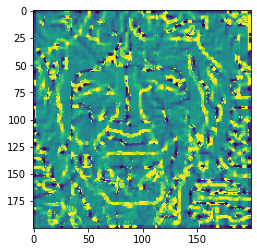

In [ ]:
test = copy.deepcopy (Xtest[20])
plt.imshow (lbp.filtrer(test))
lbp.describe (test)

Text(0.5, 1.0, 'Filtre LBP')

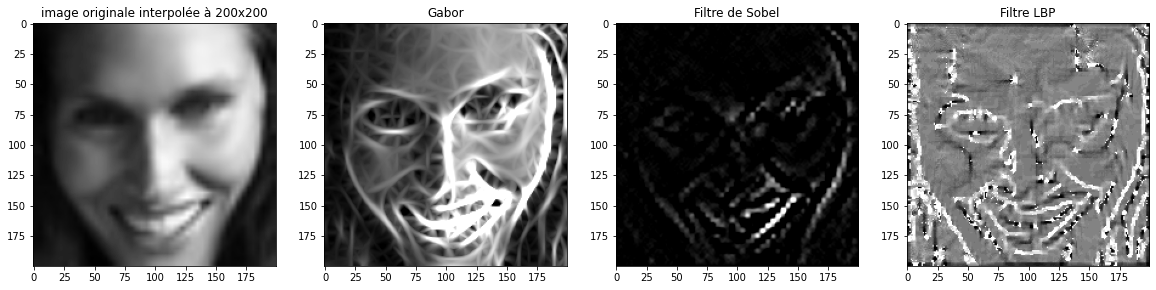

In [ ]:
image_visualisation = copy.deepcopy (Xtest[7])
plt.figure(figsize=(20, 20))
plt.subplot(1, 4, 1)
plt.imshow (image_visualisation, cmap=plt.get_cmap('gray'))
plt.title ("image originale interpolée à 200x200")
plt.subplot(1, 4, 2)
plt.imshow (process(image_visualisation, filters), cmap=plt.get_cmap('gray'))
plt.title ("Gabor")
plt.subplot(1, 4, 3)
plt.imshow (cv2.Sobel(image_visualisation, cv2.CV_8U, 1, 1, ksize = 5), cmap=plt.get_cmap('gray'))
plt.title ("Filtre de Sobel")
plt.subplot(1, 4, 4)
plt.imshow (lbp.filtrer(image_visualisation), cmap=plt.get_cmap('gray'))
plt.title ("Filtre LBP")

***Import de primitives extraites par l'histogramme du filtre LBP***

In [ ]:
# Création des vecteurs de primitives LBP
Xtrain_LBP = np.zeros ((np.shape(Xtrain)[0], 26))
Xtest_LBP = np.zeros ((np.shape(Xtest)[0], 26))
Xval_LBP =  np.zeros ((np.shape(Xval)[0], 26))

# Train
for i in range(np.shape(Xtrain)[0]):
    Xtrain_LBP[i] = lbp.describe(Xtrain[i]).flatten()

# Train
for i in range(np.shape(Xtest)[0]):
    Xtest_LBP[i] = lbp.describe(Xtest[i]).flatten()

# Test
for i in range(np.shape(Xval)[0]):
    Xval_LBP[i] = lbp.describe(Xval[i]).flatten()

Import de la dataset FG-NET

# Partie 1: Machines à vecteurs de support (SVM)
## (FER et FG-NET dataset)

Dans cette partie vous devez explorer les <b> différentes noyaux du SVM </b> disponibles dans LIBSVM, comme linéaire, polynomial et RBF.

Vous devez comparer la performance de ces algorithmes pour les ensemble FER (classification) et FG-NET (régression)

## (1a) Créer et évaluer des modèles SVM de classification
### (FER dataset)

[Scikit-learn LibSVM](https://scikit-learn.org/stable/modules/svm.html)

##### À faire:
1. Vecteurs de primitives << artisanales >> (handcrafted sans/avec réduction) du laboratoire 1. Choisir une seule représentation (p. ex. LBP après PCA). N’oubliez pas de normaliser les vecteurs (entrées) entre 0 et 1.
2. Vecteurs de primitives << deep >> (CNN features sans/avec réduction) du laboratoire 2. Choisir une seule représentation (p. ex. 1re couche entièrement connectée du CNN simple). Vous pouvez également appliquer un algorithme de réduction de la dimensionnalité pour réduire la dimension de ce vecteur. N’oubliez pas de normaliser les vecteurs (entrées) entre 0 et 1.
3. Pour chaque représentation (artisanale et deep):<br>
3a. Entraîner et optimiser (C) un SVM linéaire <br>
3b. Entraîner et optimiser (C et ordre) un SVM polynomial <br>
3c. Entraîner et optimiser (C et gamma) un SVM RBF (Gaussian) <br>
4. Analyser les résultats et présenter vos conclusions sur les modèles SVM.

|  Primitive   | Noyau       |   Paramètres    |  % App | % Val  | % Tst  |
|--------------|-------------|-----------------|--------|--------|--------|
| LBP avec PCA | lineaire    | C=10            | XXX.XX | XXX.XX |        |
| LBP avec PCA | polynomial  | C=1,d=3         |  10.45 |        |        |
| LBP avec PCA | RBF         | C=256, g=0.05   | XXX.XX | XXX.XX | XXX.XX |
| CNN 4096     | lineaire    | C=10            | XXX.XX | XXX.XX |        |
| CNN 4096     | polynomial  | C=1,d=3         |  10.45 |        |        |
| CNN 4096     | RBF         | C=256, g=0.05   | XXX.XX | XXX.XX |        |


### (1a): Code:

***LBP avec PCA***

In [ ]:
pca = PCA(n_components=3, svd_solver='auto')
pca.fit(Xtrain_LBP)

PCA(n_components=3)

In [ ]:
xpca_train = pca.transform(Xtrain_LBP)
xpca_test = pca.transform(Xtest_LBP)
xpca_eval = pca.transform(Xval_LBP)

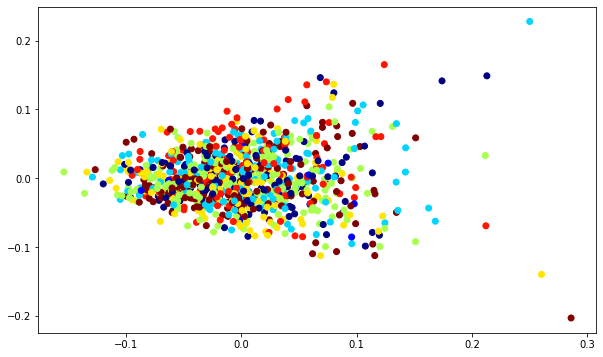

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(xpca_train[:1000, 0], xpca_train[:1000, 1], c=ytrain[:1000], cmap=plt.cm.get_cmap('jet', 10))
plt.show()

In [ ]:
# Normaliser le vecteur de primitives LBP
xpca_train_norm = (xpca_train - np.mean(xpca_train, axis=0)
                   ) / np.std(xpca_train, axis=0)
xpca_test_norm = (xpca_test - np.mean(xpca_test, axis=0)) / \
    np.std(xpca_test, axis=0)
xpca_eval_norm = (xpca_eval - np.mean(xpca_eval, axis=0)) / \
    np.std(xpca_eval, axis=0)

#### <font color='red'>**primitives artisanales (LBP)**

###### <font color='blue'>**extraction des 3 meilleures primitives via PCA**

In [ ]:
pca = PCA(n_components=3, svd_solver='auto')
pca.fit(Xtrain_LBP)

PCA(n_components=3)

In [ ]:
# proportion de variance expliquée par les différentes composantes

print (pca.explained_variance_ratio_)
print (np.sum (pca.explained_variance_ratio_))

[0.56462415 0.2873022  0.05806013]
0.909986479323676


In [ ]:
xpca_train = pca.transform(Xtrain_LBP)
xpca_test = pca.transform(Xtest_LBP)
xpca_eval = pca.transform(Xval_LBP)

In [ ]:
# Normaliser le vecteur de primitives LBP
xpca_train_norm = (xpca_train - np.mean(xpca_train, axis=0)
                   ) / np.std(xpca_train, axis=0)
xpca_test_norm = (xpca_test - np.mean(xpca_test, axis=0)) / \
    np.std(xpca_test, axis=0)
xpca_eval_norm = (xpca_eval - np.mean(xpca_eval, axis=0)) / \
    np.std(xpca_eval, axis=0)

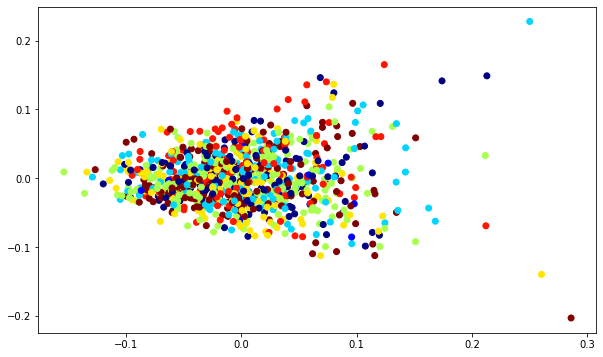

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(xpca_train[:1000, 0], xpca_train[:1000, 1], c=ytrain[:1000], cmap=plt.cm.get_cmap('jet', 10))
plt.show()

###### **SVM linéaire**

In [ ]:
# conseil du chargé de cours : faire varier C sur une échelle logarithmique
param_grid = [{'C': [1e-3, 1e-2, 1e-1, 1e+0, 1e+1, 1e+2, 1e+3], 'kernel': ['linear']}]

In [ ]:
# code REPRIS A : https://www.youtube.com/watch?v=w_bLGK4Pteo
k = 500
index = np.random.choice(xpca_train_norm.shape[0], k, replace=False)

clf = GridSearchCV(SVC(), param_grid, scoring='accuracy', cv = 3)
clf.fit(xpca_train_norm[index], ytrain[index])
print(clf.best_params_)

{'C': 0.1, 'kernel': 'linear'}


In [ ]:
# SVM
lin_clf = svm.LinearSVC(C=0.001)
lin_clf.fit(xpca_train_norm, ytrain)

LinearSVC(C=0.001)

In [ ]:
print('La précision avec les données de training est de  : ',
      accuracy_score(ytrain, lin_clf.predict(xpca_train_norm)) *100, '%.')
print('La précision avec les données de test est de  : ',
      accuracy_score(ytest, lin_clf.predict(xpca_test_norm))*100, '%.')
print('La précision avec les données évaluation est de  : ',
      accuracy_score(yval, lin_clf.predict(xpca_eval_norm))*100, '%.')

La précision avec les données de training est de  :  25.528579887840053 %.
La précision avec les données de test est de  :  24.85371969908052 %.
La précision avec les données évaluation est de  :  25.43884090275843 %.


Text(0.5, 1.0, 'Histogramme des données prédites')

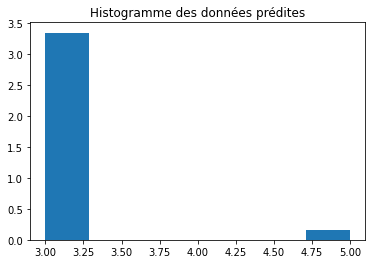

In [ ]:
# Analyse des données prédites

plt.hist (lin_clf.predict(xpca_test_norm), bins = 7, density = True)
plt.title('Histogramme des données prédites')

In [ ]:
### Modèle très underfit et ne fait que prédire une classe quasiment

###### **SVM polynomial**

In [ ]:
##### polynomial
k = 500
index = np.random.choice(xpca_train_norm.shape[0], k, replace=False)

clf = GridSearchCV(SVC(), param_grid_pol, scoring='accuracy', cv = 3)
clf.fit(xpca_train_norm[index], ytrain[index])
print(clf.best_params_)

{'C': 1.0, 'degree': 2}


In [ ]:
# SVM
pol_clf = svm.SVC(C=1, degree=2)
pol_clf.fit(xpca_train_norm, ytrain)

SVC(C=1, degree=2)

In [ ]:
print('La précision avec les données de training est de  : ',
      accuracy_score(ytrain, pol_clf.predict(xpca_train_norm)) *100, '%.')
print('La précision avec les données de test est de  : ',
      accuracy_score(ytest, pol_clf.predict(xpca_test_norm))*100, '%.')

La précision avec les données de training est de  :  25.96746664808945 %.
La précision avec les données de test est de  :  24.90944552800223 %.


###### **SVM RBF**

In [ ]:
##### rbf
k = 500
index = np.random.choice(xpca_train_norm.shape[0], k, replace=False)

clf = GridSearchCV(SVC(), param_grid_rbf, scoring='accuracy', cv = 3)
clf.fit(xpca_train_norm[index], ytrain[index])
print(clf.best_params_)

{'C': 0.01, 'gamma': 0.1, 'kernel': 'rbf'}


In [ ]:
# SVM
rbf_clf = svm.SVC(C=0.01, kernel='rbf', gamma = 0.1)
rbf_clf.fit(xpca_train_norm, ytrain)

SVC(C=0.01, gamma=0.1)

In [ ]:
print('La précision avec les données de training est de  : ',
      accuracy_score(ytrain, rbf_clf.predict(xpca_train_norm)) *100, '%.')
print('La précision avec les données de test est de  : ',
      accuracy_score(ytest, rbf_clf.predict(xpca_test_norm))*100, '%.')

La précision avec les données de training est de  :  25.13149186666202 %.
La précision avec les données de test est de  :  24.49150181108944 %.


###### <font color='blue'>**transformation de l'espace par LDA**

In [ ]:
lda = LinearDiscriminantAnalysis()
lda.fit (Xtrain_LBP, ytrain)

LinearDiscriminantAnalysis()

In [ ]:
xlda_train = lda.transform(Xtrain_LBP)
xlda_test = lda.transform(Xtest_LBP)
xlda_eval = lda.transform(Xval_LBP)

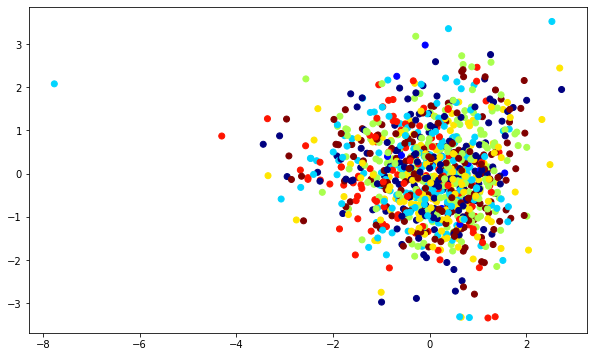

In [ ]:
# affichage du nuage de points
plt.figure(figsize=(10, 6))
plt.scatter(xlda_train[:1000, 0], xlda_train[:1000, 1], c=ytrain[:1000], cmap=plt.cm.get_cmap('jet', 10))
plt.show()

#### <font color='red'>**Filtres de convolution**

###### <font color='blue'>**Création du CNN simple**

###### **Pour cette partie, le code est basé sur celui fourni par le chargé de laboratoire**

In [ ]:
def define_modele_simple ():
    modele_simple_CNN = tf.keras.Sequential([
        Conv2D(2, (2, 2), input_shape=(200, 200, 1), padding='same', activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(7, activation='softmax')
    ])

    modele_simple_CNN.compile(optimizer='adam',
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])

    return (modele_simple_CNN)

In [ ]:
def entrainer_modele (modele_simple_CNN, Xtrain, ytrain) :
    k = np.shape(Xtrain)[0]
    index = np.random.choice(Xtrain.shape[0], k, replace=False)
    modele_simple_CNN.fit(np.reshape (Xtrain, (np.shape(Xtrain)[0], 200, 200, 1))[index], ytrain[index], epochs = 7, verbose = 2)
    return (modele_simple_CNN)

In [ ]:
scaled_Train_Model = define_modele_simple()
scaled_Train_Trained = entrainer_modele(scaled_Train_Model, Xtrain, ytrain)

Epoch 1/7
898/898 - 96s - loss: 1.9971 - accuracy: 0.1684
Epoch 2/7
898/898 - 97s - loss: 1.9971 - accuracy: 0.1684
Epoch 3/7
898/898 - 96s - loss: 1.9971 - accuracy: 0.1684
Epoch 4/7
898/898 - 99s - loss: 1.9971 - accuracy: 0.1684
Epoch 5/7
898/898 - 97s - loss: 1.9971 - accuracy: 0.1684
Epoch 6/7
898/898 - 98s - loss: 1.9971 - accuracy: 0.1684
Epoch 7/7
898/898 - 107s - loss: 1.9971 - accuracy: 0.1684


In [ ]:
# evaluation du modele
model_info_val = modele_simple_CNN.evaluate(np.reshape (Xval, (np.shape(Xval)[0], 200, 200, 1)),  yval, verbose=2)[1] # test accuracy

113/113 - 7s - loss: 1.9834 - accuracy: 0.1819


In [ ]:
# extraction de primitives
predited_scaled_Xtrain = scaled_Train_Model.predict(np.reshape (Xtrain, (np.shape(Xtrain)[0], 200, 200, 1)))
predited_scaled_Xtest = scaled_Train_Model.predict(np.reshape (Xval, (np.shape(Xval)[0], 200, 200, 1)))

In [ ]:
#conseil du chargé de cours : faire varier C sur une échelle logarithmique
param_grid_lin = [{'C': [1e-3, 1e-2, 1e-1, 1e+0, 1e+1, 1e+2, 1e+3], 'kernel': ['linear']}]
param_grid_pol = [{'C': [1e-2, 1e-1, 1e+0, 1e+1, 1e+2, 1e3], 'degree': [2, 3, 4]}]
param_grid_rbf = [{'C': [1e-2, 1e-1, 1e+0, 1e+1, 1e+2], 'gamma': [0.1, 0.25, 0.5, 2],  'kernel': ['rbf']}]

###### <font color='blue'>**Comparaisons des différents modèles de SVM**

###### **SVM linéaire**

In [ ]:
##### Linéaire
k = 500
index = np.random.choice(predited_scaled_Xtrain.shape[0], k, replace=False)

clf = GridSearchCV(SVC(), param_grid_lin, scoring='accuracy', cv = 3)
clf.fit(predited_scaled_Xtrain[index], ytrain[index])
print(clf.best_params_)

{'C': 0.001, 'kernel': 'linear'}


In [ ]:
# SVM
lin_clf = svm.LinearSVC(C=0.001)
lin_clf.fit(predited_scaled_Xtrain, ytrain)

LinearSVC(C=0.001)

In [ ]:
print('La précision avec les données de training est de  : ',
      accuracy_score(ytrain, lin_clf.predict(predited_scaled_Xtrain)) *100, '%.')
print('La précision avec les données de test est de  : ',
      accuracy_score(ytest, lin_clf.predict(predited_scaled_Xtest))*100, '%.')

La précision avec les données de training est de  :  25.13149186666202 %.
La précision avec les données de test est de  :  24.49150181108944 %.


###### **SVM polynomial**

In [ ]:
##### polynomial
k = 500
index = np.random.choice(predited_scaled_Xtrain.shape[0], k, replace=False)

clf = GridSearchCV(SVC(), param_grid_pol, scoring='accuracy', cv = 3)
clf.fit(predited_scaled_Xtrain[index], ytrain[index])
print(clf.best_params_)

{'C': 0.01, 'degree': 2}


In [ ]:
# SVM
pol_clf = svm.SVC(C=0.01, degree=2)
pol_clf.fit(predited_scaled_Xtrain, ytrain)

SVC(C=0.01, degree=2)

In [ ]:
print('La précision avec les données de training est de  : ',
      accuracy_score(ytrain, pol_clf.predict(predited_scaled_Xtrain)) *100, '%.')
print('La précision avec les données de test est de  : ',
      accuracy_score(ytest, pol_clf.predict(predited_scaled_Xtest))*100, '%.')

La précision avec les données de training est de  :  25.13149186666202 %.
La précision avec les données de test est de  :  24.49150181108944 %.


###### **SVM RBF**

In [ ]:
##### rbf
k = 500
index = np.random.choice(predited_scaled_Xtrain.shape[0], k, replace=False)

clf = GridSearchCV(SVC(), param_grid_rbf, scoring='accuracy', cv = 3)
clf.fit(predited_scaled_Xtrain[index], ytrain[index])
print(clf.best_params_)

{'C': 0.01, 'gamma': 0.1, 'kernel': 'rbf'}


In [ ]:
# SVM
rbf_clf = svm.SVC(C=0.01, kernel='rbf', gamma = 0.1)
rbf_clf.fit(predited_scaled_Xtrain, ytrain)

SVC(C=0.01, gamma=0.1)

In [ ]:
print('La précision avec les données de training est de  : ',
      accuracy_score(ytrain, rbf_clf.predict(predited_scaled_Xtrain)) *100, '%.')
print('La précision avec les données de test est de  : ',
      accuracy_score(ytest, rbf_clf.predict(predited_scaled_Xtest))*100, '%.')

La précision avec les données de training est de  :  25.13149186666202 %.
La précision avec les données de test est de  :  24.49150181108944 %.


***Import de primitives extraites par la concaténation d'histogrammes de sous-images filtrées avec LBP***

In [ ]:
NB_BLOCS_PAR_COTE = 6 # 36 sous-images

# Création des vecteurs de primitives LBP
Xtrain_LBP = np.zeros ((np.shape(Xtrain)[0], 26 * NB_BLOCS_PAR_COTE * NB_BLOCS_PAR_COTE))
Xtest_LBP = np.zeros ((np.shape(Xtest)[0], 26 * NB_BLOCS_PAR_COTE * NB_BLOCS_PAR_COTE))
Xval_LBP =  np.zeros ((np.shape(Xval)[0], 26 * NB_BLOCS_PAR_COTE * NB_BLOCS_PAR_COTE))

# Train
for i in range(np.shape(Xtrain)[0]):
    Xtrain_LBP[i] = lbp.describe_per_bloc(Xtrain[i], NB_BLOCS_PAR_COTE)

# Train
for i in range(np.shape(Xtest)[0]):
    Xtest_LBP[i] = lbp.describe_per_bloc(Xtest[i], NB_BLOCS_PAR_COTE)

# Test
for i in range(np.shape(Xval)[0]):
    Xval_LBP[i] = lbp.describe_per_bloc(Xval[i], NB_BLOCS_PAR_COTE)


In [ ]:
lda = LinearDiscriminantAnalysis()
lda.fit (Xtrain_LBP, ytrain)

LinearDiscriminantAnalysis()

In [ ]:
xlda_train = lda.transform(Xtrain_LBP)
xlda_test = lda.transform(Xtest_LBP)
xlda_eval = lda.transform(Xval_LBP)

In [ ]:
# Normaliser le vecteur de primitives LBP
xlda_train_norm = (xlda_train - np.mean(xlda_train, axis=0)
                   ) / np.std(xlda_train, axis=0)
xlda_test_norm = (xlda_test - np.mean(xlda_test, axis=0)) / \
    np.std(xlda_test, axis=0)
xlda_eval_norm = (xlda_eval - np.mean(xlda_eval, axis=0)) / \
    np.std(xlda_eval, axis=0)

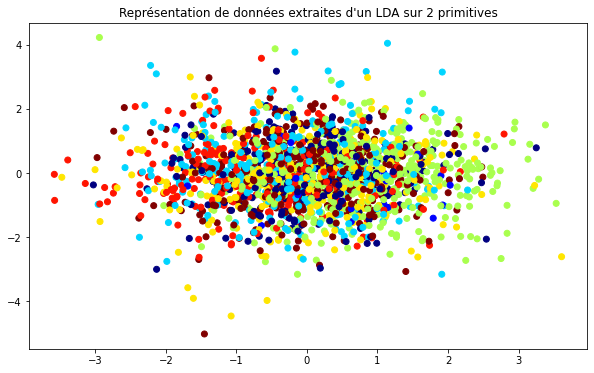

In [ ]:
# affichage du nuage de points des données de test
plt.figure(figsize=(10, 6))
plt.title ("Représentation de données extraites d'un LDA sur 2 primitives")
plt.scatter(xlda_test[:2000, 0], xlda_test[:2000, 5], c=ytest[:2000], cmap=plt.cm.get_cmap('jet', 10))
plt.show()

In [ ]:
# code REPRIS A : https://www.youtube.com/watch?v=w_bLGK4Pteo
k = 500
index = np.random.choice(xlda_train_norm.shape[0], k, replace=False)

clf = GridSearchCV(SVC(), param_grid_lin, scoring='accuracy', cv = 3)
clf.fit(xlda_train_norm[index], ytrain[index])
print(clf.best_params_)

{'C': 10.0, 'kernel': 'linear'}


In [ ]:
# SVM
lin_clf = svm.LinearSVC(C=10)
lin_clf.fit(xlda_train_norm, ytrain)

C:\Users\maxime_delboulle\anaconda3\lib\site-packages\sklearn\svm\_base.py:985: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to converge, increase "


LinearSVC(C=10)

In [ ]:
print('La précision avec les données de training est de  : ',
      accuracy_score(ytrain, lin_clf.predict(xlda_train_norm)) *100, '%.')
print('La précision avec les données de test est de  : ',
      accuracy_score(ytest, lin_clf.predict(xlda_test_norm))*100, '%.')
print('La précision avec les données évaluation est de  : ',
      accuracy_score(yval, lin_clf.predict(xlda_eval_norm))*100, '%.')

La précision avec les données de training est de  :  41.011529485527184 %.
La précision avec les données de test est de  :  33.6862635831708 %.
La précision avec les données évaluation est de  :  33.04541655057119 %.


***Import de primitives extraites par la concaténation d'histogrammes de sous-images filtrées avec LBP***

In [ ]:
NB_BLOCS_PAR_COTE = 10 # 100 sous-images

# Création des vecteurs de primitives LBP
Xtrain_LBP = np.zeros ((np.shape(Xtrain)[0], 26 * NB_BLOCS_PAR_COTE * NB_BLOCS_PAR_COTE))
Xtest_LBP = np.zeros ((np.shape(Xtest)[0], 26 * NB_BLOCS_PAR_COTE * NB_BLOCS_PAR_COTE))
Xval_LBP =  np.zeros ((np.shape(Xval)[0], 26 * NB_BLOCS_PAR_COTE * NB_BLOCS_PAR_COTE))

# Train
for i in range(np.shape(Xtrain)[0]):
    Xtrain_LBP[i] = lbp.describe_per_bloc(Xtrain[i], NB_BLOCS_PAR_COTE)

# Train
for i in range(np.shape(Xtest)[0]):
    Xtest_LBP[i] = lbp.describe_per_bloc(Xtest[i], NB_BLOCS_PAR_COTE)

# Test
for i in range(np.shape(Xval)[0]):
    Xval_LBP[i] = lbp.describe_per_bloc(Xval[i], NB_BLOCS_PAR_COTE)


In [ ]:
xpca_train = pca.transform(Xtrain_LBP)
xpca_test = pca.transform(Xtest_LBP)
xpca_eval = pca.transform(Xval_LBP)

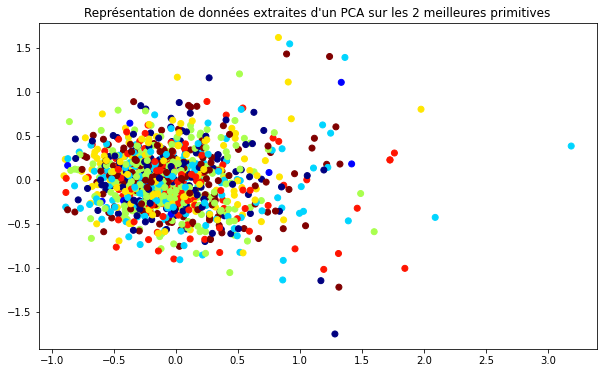

In [ ]:
plt.figure(figsize=(10, 6))
plt.title ("Représentation de données extraites d'un PCA sur les 2 meilleures primitives")
plt.scatter(xpca_train[:1000, 0], xpca_train[:1000, 1], c=ytrain[:1000], cmap=plt.cm.get_cmap('jet', 10))
plt.show()

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()
lda.fit (Xtrain_LBP, ytrain)

LinearDiscriminantAnalysis()

In [ ]:
xlda_train = lda.transform(Xtrain_LBP)
xlda_test = lda.transform(Xtest_LBP)
xlda_eval = lda.transform(Xval_LBP)

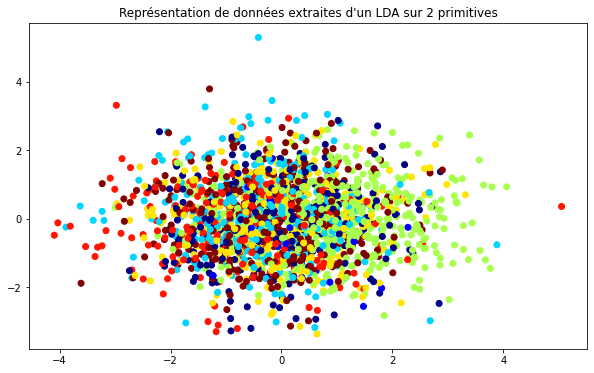

In [ ]:
# affichage du nuage de points des données de test
plt.figure(figsize=(10, 6))
plt.title ("Représentation de données extraites d'un LDA sur 2 primitives")
plt.scatter(xlda_test[:2000, 0], xlda_test[:2000, 5], c=ytest[:2000], cmap=plt.cm.get_cmap('jet', 10))
plt.show()

In [ ]:
# Normaliser le vecteur de primitives LBP
xlda_train_norm = (xlda_train - np.mean(xlda_train, axis=0)
                   ) / np.std(xlda_train, axis=0)
xlda_test_norm = (xlda_test - np.mean(xlda_test, axis=0)) / \
    np.std(xlda_test, axis=0)
xlda_eval_norm = (xlda_eval - np.mean(xlda_eval, axis=0)) / \
    np.std(xlda_eval, axis=0)

###### **SVM linéaire**

In [ ]:
# code REPRIS A : https://www.youtube.com/watch?v=w_bLGK4Pteo
k = 500
index = np.random.choice(xlda_train_norm.shape[0], k, replace=False)

clf = GridSearchCV(SVC(), param_grid_lin, scoring='accuracy', cv = 3)
clf.fit(xlda_train_norm[index], ytrain[index])
print(clf.best_params_)

{'C': 0.1, 'kernel': 'linear'}


In [ ]:
# SVM
lin_clf = svm.LinearSVC(C=0.1)
lin_clf.fit(xlda_train_norm, ytrain)

LinearSVC(C=0.1)

In [ ]:
print('La précision avec les données de training est de  : ',
      accuracy_score(ytrain, lin_clf.predict(xlda_train_norm)) *100, '%.')
print('La précision avec les données de test est de  : ',
      accuracy_score(ytest, lin_clf.predict(xlda_test_norm))*100, '%.')
print('La précision avec les données évaluation est de  : ',
      accuracy_score(yval, lin_clf.predict(xlda_eval_norm))*100, '%.')

La précision avec les données de training est de  :  52.875404925284755 %.
La précision avec les données de test est de  :  36.416829200334355 %.
La précision avec les données évaluation est de  :  36.02674839788242 %.


Text(0.5, 1.0, 'Histogramme des données prédites')

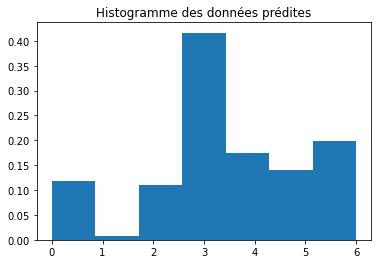

In [ ]:
# Analyse des données prédites

plt.hist (lin_clf.predict(xlda_test_norm), bins = 7, density = True)
plt.title('Histogramme des données prédites')

###### **SVM polynomial**

In [ ]:
##### polynomial
k = 500
index = np.random.choice(xlda_train_norm.shape[0], k, replace=False)

clf = GridSearchCV(SVC(), param_grid_pol, scoring='accuracy', cv = 3)
clf.fit(xlda_train_norm[index], ytrain[index])
print(clf.best_params_)

{'C': 1.0, 'degree': 2}


In [ ]:
# SVM
pol_clf = svm.SVC(C=1, degree=2)
pol_clf.fit(xlda_train_norm, ytrain)

SVC(C=1, degree=2)

In [ ]:
print('La précision avec les données de training est de  : ',
      accuracy_score(ytrain, pol_clf.predict(xlda_train_norm)) *100, '%.')
print('La précision avec les données de test est de  : ',
      accuracy_score(ytest, pol_clf.predict(xlda_test_norm))*100, '%.')
print('La précision avec les données évaluation est de  : ',
      accuracy_score(yval, pol_clf.predict(xlda_eval_norm))*100, '%.')

La précision avec les données de training est de  :  53.92037340206903 %.
La précision avec les données de test est de  :  36.16606297018668 %.
La précision avec les données évaluation est de  :  35.91529674003901 %.


Text(0.5, 1.0, 'Histogramme des données prédites')

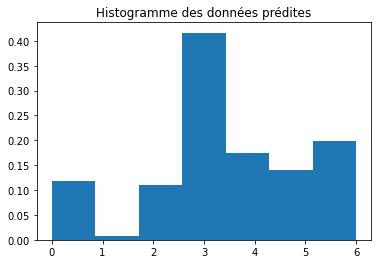

In [ ]:
# Analyse des données prédites

plt.hist (lin_clf.predict(xlda_test_norm), bins = 7, density = True)
plt.title('Histogramme des données prédites')

###### **SVM RBF**

In [ ]:
##### rbf
k = 500
index = np.random.choice(xlda_train_norm.shape[0], k, replace=False)

clf = GridSearchCV(SVC(), param_grid_rbf, scoring='accuracy', cv = 3)
clf.fit(xlda_train_norm[index], ytrain[index])
print(clf.best_params_)

{'C': 1.0, 'gamma': 0.1, 'kernel': 'rbf'}


In [ ]:
# SVM
rbf_clf = svm.SVC(C=1, kernel='rbf', gamma = 0.1)
rbf_clf.fit(xlda_train_norm, ytrain)

SVC(C=1, gamma=0.1)

In [ ]:
print('La précision avec les données de training est de  : ',
      accuracy_score(ytrain, rbf_clf.predict(xlda_train_norm)) *100, '%.')
print('La précision avec les données de test est de  : ',
      accuracy_score(ytest, rbf_clf.predict(xlda_test_norm))*100, '%.')
print('La précision avec les données évaluation est de  : ',
      accuracy_score(yval, rbf_clf.predict(xlda_eval_norm))*100, '%.')

La précision avec les données de training est de  :  53.59991640252185 %.
La précision avec les données de test est de  :  35.88743382557816 %.
La précision avec les données évaluation est de  :  35.74811925327389 %.


Text(0.5, 1.0, 'Histogramme des données prédites')

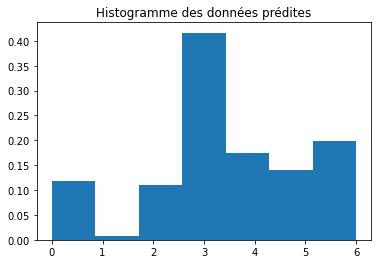

In [ ]:
# Analyse des données prédites

plt.hist (lin_clf.predict(xlda_test_norm), bins = 7, density = True)
plt.title('Histogramme des données prédites')

### (1a): Résultats et résponses:

<font color='blue'> Voici les résultats obtenus suivant les différents modèles et les différentes techniques d'extraction de primitives.


|  Primitive   | Noyau       |   Paramètres    |  % train | % Val  | % Test  |
|--------------|-------------|-----------------|--------|--------|--------|
| LBP avec PCA | lineaire    | C=0.001            | 25.53 | 24.85 | 25.44       |
| LBP avec PCA | polynomial    | C=0.001 deg = 2 | 25.97 | 24.91 | N.A.       |
| LBP avec PCA | RBF    | C=0.001 gamma = 0.1 | 25.13 | 24.49 | N.A.       |
| CNN simple     | lineaire    | C=0.001  | 25.13 | 24.49 |   N.A.      |
| CNN simple     | polynomial    | C=0.01 deg = 2 | 25.13 | 24.49 |   N.A.      |
| CNN simple     | RBF    | C=0.01  gamma = 0.1  | 25.13 | 24.49 |   N.A. |
| LBPH 36 avec LDA | linéaire  | C=10 | 41.01 | 33.68 | 33.04 |
| LBPH 100 avec LDA | linéaire   | C=1  | 52.88 | 36.42 | 36.03 |
| LBPH 100 avec LDA | polynomial | C=1, deg = 2  | 53.92 | 36.17 | 35.92 |
| LBPH 100 avec LDA | RBF         | C=1 gamma=0.1  | 54.00 | 35.89 | 35.75 |

<font color='blue'> L'extraction de primitives par LBP avec concaténation d'histogrammes (LBPH) a considérablement amélioré le pouvoir prédictif de notre modèle. Toutes les primitives extraites par LPB avec PCA et CNN sont des données très peu interprétables. Des nuages de points dans le code prouvaient que les classes étaient mélangées et qu'il n'existait aucun frontière visible. Le modèle conseillé va être celui ayant le C le plus bas (variance basse), ce qui incite le modèle à prédire tout le temps la même classe (celle ayant la proportion la plus élevée dans les données). Ainsi, les résulats sont proches et paraissent élevées (environ 25 %). Plusieurs histogrammes de prédiction montrent que le modèle bloque sur une classe majoritairement.

<font color='blue'> Nous pouvons observer qu'il y a peu de différence entre les différents types de noyaux de SVM. Cela est dû au fait que les données sont linéairement séparables. En effet, les nuages de points issues des données de test transformées par LDA sont linéairement séparables (visuellement).

<font color='blue'> Les valeurs optimales de C sont plus cohérentes (proches de 1 ou 10). Les résultats de prédiction avoisinent les 36 % pour les données de test.

<font color='blue'> Les histogrammes de prédiction de classe sont cohérentes avec la proportion de classe des données. Le modèle essaie vraiment de séparer les données.

<font color='blue'> Pour la partie 1.b, nous utiliserons les primitives LBPH à 100 sous-images transformées par LDA avec un SVM linéaire C = 1, car c'est le meilleur modèle dont nous disposons.


## (1b) Créer et évaluer des modèles de régression
### (FG-NET dataset)

Idéalement, vous devez tout refaire pour ce nouvel ensemble de données / tâche. Alors, pour simplifier ce TP, vous pouvez créer, optimiser et évaluer un seul modèle de régression. Vous pouvez choisir la meilleure combinaison représentation / SVM de la partie 1a.
<font color=blue>
##### À faire:
1. Choisir une combinaison primitive/kernel (Cellui qu'a meilleur performé dans la partie 1).
2. Entraîner et optimiser (C, epsilon, ???) un SRV (linéaire ou polynomial ou Gaussian)
3. Analyser les résultats et présenter vos conclusions sur le modèle SVR.

|  Primitive   | Noyau    |   Paramètres       |  MAE   |  MSE   |
|--------------|----------|--------------------|--------|--------|
| LBP avec PCA |  RBF     | C=256,g=15,ep=0.1  | XXX.XX | XXX.XX |
</font>    

### (1b): Code:

In [ ]:
if (constante_L_D == 'DRIVE'):
    dir = '/content/drive/Shareddrives/GTI771/FGNET/images/'
else :
    dir = 'images/'
images = []
attributes_image_age = []  # stocke les attributs des images (âge)
attributes_image_matricule = []  # stocke les attributs des images (matricule)

for root, dirs, files in os.walk(top=dir):  # On récupère les fichiers JPG
  for name in files:
    extension = os.path.splitext(name)[1]
    if extension.upper() == '.JPG':
      # We can read the data here
      images += [Image.open(dir + name)]
      # split age & matricule
      attributes_image_matricule += [int(name[0:3])]
      attributes_image_age += [int(name[4:6])]

In [ ]:
# Data reshape vers dimension 1 les vraies dimensions
reshape_images = []
image_dimension_largeur = []
image_dimension_longueur = []
for image_pixel in images:
  image_pixel = image_pixel.convert('L')
  dimension = np.shape(image_pixel)
  image_dimension_largeur += [int(dimension[0])]
  image_dimension_longueur += [int(dimension[1])]
  image_pixel = np.resize(image_pixel, dimension)
  reshape_images += [np.array(image_pixel)]

In [ ]:
# redimensionnement commun vers 2 dimensions
images_cv2 = []

for root, dirs, files in os.walk(top=dir):  # On récupère les fichiers JPG
  for name in files:
    extension = os.path.splitext(name)[1]
    if extension.upper() == '.JPG':
      # We can read the data here
      image_cv2 = cv2.imread(dir + name, 0)
      images_cv2 += [cv2.resize(image_cv2, (500, 500))]

###### Appliquer LBPH sur FG-NET

In [ ]:
radius = 3
points = 24
lbp = LocalBinaryPatterns(points, radius)

In [ ]:
NB_BLOCS_PAR_COTE = 10  # 100 sous-images

# Création des vecteurs de primitives LBP
FGNET_X_LBP = np.zeros((len(images_cv2), 26 * NB_BLOCS_PAR_COTE * NB_BLOCS_PAR_COTE))

for i in range(0, 1001):
    FGNET_X_LBP[i] = lbp.describe_per_bloc(images_cv2[i], NB_BLOCS_PAR_COTE)

######Séparation des données en training(80%), test(10%) et évaluation(10%)


In [ ]:
Xtrain_FGNET = FGNET_X_LBP[0:800]
Xtest_FGNET = FGNET_X_LBP[801:901]
Xval_FGNET = FGNET_X_LBP[902:1002]

ytrain_FGNET = np.asarray(attributes_image_age[0:800])
ytest_FGNET = np.asarray(attributes_image_age[801:901])
yval_FGNET = np.asarray(attributes_image_age[902:1002])

######Appliquer PCA et selectionner les trois premiers composants.

In [ ]:
# pca = PCA(n_components=3, svd_solver='auto')
# pca.fit(Xtrain_FGNET)
lda = LinearDiscriminantAnalysis()
lda.fit (Xtrain_FGNET, ytrain_FGNET)
xlda_FGNET_train = lda.transform(Xtrain_FGNET)
xlda_FGNET_test = lda.transform(Xtest_FGNET)
xlda_FGNET_eval = lda.transform(Xval_FGNET)

###### Normalisaton des données


In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
xlda_FGNET_train_norm = scaler.fit_transform(xlda_FGNET_train)
xlda_FGNET_test_norm = scaler.fit_transform(xlda_FGNET_test)
xlda_FGNET_eval_norm = scaler.fit_transform(xlda_FGNET_eval)

xlda_FGNET_train_norm.shape, xlda_FGNET_test_norm.shape, xlda_FGNET_eval_norm.shape

((800, 62), (100, 62), (100, 62))

##### SVM Linéaire sans optimisation

In [ ]:
model = svm.LinearSVC()
model.fit(xlda_FGNET_train_norm, ytrain_FGNET)
model.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': True,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'loss': 'squared_hinge',
 'max_iter': 1000,
 'multi_class': 'ovr',
 'penalty': 'l2',
 'random_state': None,
 'tol': 0.0001,
 'verbose': 0}

In [ ]:
ytrain_FGNET_pred = model.predict(xlda_FGNET_train_norm)
yval_FGNET_pred = model.predict(xlda_FGNET_eval_norm)
ytest_FGNET_pred = model.predict(xlda_FGNET_test_norm)

MAE_train_raw = mean_absolute_error(ytrain_FGNET, ytrain_FGNET_pred)
MAE_eval_raw = mean_absolute_error(yval_FGNET, yval_FGNET_pred)
MAE_test_raw = mean_absolute_error(ytest_FGNET, ytest_FGNET_pred)

print("MAE entrainement : ", str(round(MAE_train_raw, 2)))
print("MAE validation : ", str(round(MAE_eval_raw, 2)))
print("MAE test : ", str(round(MAE_test_raw, 2)))

MAE entrainement :  0.9
MAE validation :  9.7
MAE test :  9.21


In [ ]:
MSE_train_raw = mean_squared_error(ytrain_FGNET, ytrain_FGNET_pred)
MSE_eval_raw = mean_squared_error(yval_FGNET, yval_FGNET_pred)
MSE_test_raw = mean_squared_error(ytest_FGNET, ytest_FGNET_pred)

print("MSE entrainement : ", str(round(MSE_train_raw, 2)))
print("MSE validation : ", str(round(MSE_eval_raw, 2)))
print("MSE test : ", str(round(MSE_test_raw, 2)))


MSE entrainement :  12.53
MSE validation :  213.24
MSE test :  173.97


##### Optimisation

In [ ]:
param_grid = [{'C': [1e-3, 1e-2, 1e-1, 1e+0, 1e+1, 1e+2, 1e+3], 'kernel': ['linear']}]

In [ ]:
# code REPRIS A : https://www.youtube.com/watch?v=w_bLGK4Pteo
k = 800
index = np.random.choice(xlda_FGNET_train_norm.shape[0], k, replace=False)
clf = GridSearchCV(SVC(), param_grid, scoring='accuracy', cv=3)
clf.fit(xlda_FGNET_train_norm[index], ytrain_FGNET[index])
best_clf = clf.best_estimator_
print(best_clf.C)

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_split.py:680: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  UserWarning,


1.0


##### SVM Linéaire avec optimisation

In [ ]:
optimized_model = svm.LinearSVC(C=1)#best_clf.C)
optimized_model.fit(xlda_FGNET_train_norm, ytrain_FGNET)

LinearSVC(C=1)

######Mean absolute error pour les données de prédictions.

In [ ]:
ytrain_FGNET_pred = optimized_model.predict(xlda_FGNET_train_norm)
yval_FGNET_pred = optimized_model.predict(xlda_FGNET_eval_norm)
ytest_FGNET_pred = optimized_model.predict(xlda_FGNET_test_norm)

MAE_train_optimized = mean_absolute_error(ytrain_FGNET, ytrain_FGNET_pred)
MAE_eval_optimized = mean_absolute_error(yval_FGNET, yval_FGNET_pred)
MAE_test_optimized = mean_absolute_error(ytest_FGNET, ytest_FGNET_pred)

print("MAE entrainement : ", str(round(MAE_train_optimized, 2)))
print("MAE validation : ", str(round(MAE_eval_optimized, 2)))
print("MAE test : ", str(round(MAE_test_optimized, 2)))


MAE entrainement :  0.9
MAE validation :  9.7
MAE test :  9.21


######Mean squared error pour les données de prédictions.

In [ ]:
MSE_train_optimized = mean_squared_error(ytrain_FGNET, ytrain_FGNET_pred)
MSE_eval_optimized = mean_squared_error(yval_FGNET, yval_FGNET_pred)
MSE_test_optimized = mean_squared_error(ytest_FGNET, ytest_FGNET_pred)

print("MSE entrainement : ", str(round(MSE_train_optimized, 2)))
print("MSE validation : ", str(round(MSE_eval_optimized, 2)))
print("MSE test : ", str(round(MSE_test_optimized, 2)))

MSE entrainement :  12.53
MSE validation :  213.24
MSE test :  173.97


### (1b): Résultats et résponses:

**Comparaison des données optimisées et non optimisées par le prisme du MSE et du MAE**

|  Primitive   | Noyau    |   Paramètres       |  MAE   |  MSE   |
|--------------|----------|--------------------|--------|--------|
| LBP avec PCA sans optimisation |  SVM Linéaire     | C=1.0  | 9.7 | 213.24 |
| LBP avec PCA avec optimisation |  SVM Linéaire     | C=0.001  | 9.7 | 213.24 |

Le modèle n'est pas très performant. Par rapport au laboratoire n°2, nous obtenons des résultats supplémentaires.

Nous nous rendons compte que la MAE et la MSE sont extrêmement basses pour les données d'entraînement. Ceci montre que notre modèle est surentrainé. Nous disposons de peu de données et nous retenons 6 primitives parmi 2,6e+5. Or, nous ne disposons que de 800 images à l'entraînement. Il faudrait donc augmenter l'ensemble de données. 1 000 images représentent bien trop peu d'images.

# Partie 2: Combinaison des algorithmes d'apprentissage
## (FER dataset)

Vous devrez intégrer une notion supplémentaire acquise récemment dans le cours théorique, à savoir la combinaison de modèles d’apprentissage. Contrairement aux laboratoires précédents dans lesquelles vous travailliez avec des modèles indépendants sur un seul ensemble de données, vous devez dans ce présent laboratoire combiner des algorithmes d’apprentissage afin de classifier les échantillons d’un ensemble de données regroupant plusieurs sortes de primitives (feature sets). Vous implémenterez ce système avec les librairies TensorFlow ou scikit-learn. Finalement, vous aurez à proposer une stratégie combinatoire de classificateurs tel que vote de majorité, moyenne, produit, médiane, etc.

## (2a) Créer et évaluer des ensembles Bagging et Boosting

<font color=blue>
    
##### À faire:
1. Choisir un algorithme de base (AD, NB, KNN) pour construire des ensembles avec "bagging" et "boosting"
2. Entraîner et optimiser les ensembles bagging et Adaboost
3. Comparer la performance des ensembles avec des classificateurs individuels.     
4. Analyser les résultats et présenter vos conclusions sur les ensembles bagging et boosting.

|  Primitive   | Classificateur | Ensemble |  paramètres |  % App | % Val  | % Tst  |
|--------------|----------------|----------|-------------|--------|--------|--------|
| LBP avec PCA |       AD       | bagging  |ms=0.4,ne=50 | XXX.XX | XXX.XX | XXX.XX |
| LBP avec PCA |       AD       | adaboost |lr=1.0,ne=200| XXX.XX | XXX.XX | XXX.XX |    
| ...          |                |                        | XXX.XX | XXX.XX | XXX.XX |    
</font>    








### <font color=blue> (2a&b partie commune): </font>

In [ ]:
# construction des modèles de base & évaluation individuelle

In [ ]:
def afficher_evaluation_modele (modele, Xtrain, ytrain, Xtest, ytest, Xval, yval) :
    print('La précision avec les données de training est de  : ',
          accuracy_score(ytrain, modele.predict(Xtrain)) *100, '%.')
    print('La précision avec les données de test est de  : ',
          accuracy_score(ytest, modele.predict(Xtest))*100, '%.')
    print('La précision avec les données évaluation est de  : ',
          accuracy_score(yval, modele.predict(Xval))*100, '%.')

In [ ]:
# vecteurs de primitives choisis à partir de la partie 1 : xlda_train, xlda_test, xlda_eval
print (np.shape (xlda_train), np.shape (xlda_test), np.shape (xlda_eval))

(28709, 6) (3589, 6) (3589, 6)


In [ ]:
# Naive Bayes Gaussien
gnb = GaussianNB()
gnb.fit(xlda_train, ytrain)

GaussianNB()

In [ ]:
gnb.predict_proba (xlda_test)[0]

array([0.26079207, 0.00214667, 0.15955028, 0.02991438, 0.33620342,
       0.03903744, 0.17235574])

In [ ]:
afficher_evaluation_modele (gnb, xlda_train, ytrain, xlda_test, ytest, xlda_eval, yval)

La précision avec les données de training est de  :  53.37002333762931 %.
La précision avec les données de test est de  :  36.05461131234327 %.
La précision avec les données évaluation est de  :  35.74811925327389 %.


In [ ]:
neigh = KNeighborsClassifier(n_neighbors=3)

In [ ]:
neigh.fit(xlda_train, ytrain)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
afficher_evaluation_modele (neigh, xlda_train, ytrain, xlda_test, ytest, xlda_eval, yval)

La précision avec les données de training est de  :  66.09773938486188 %.
La précision avec les données de test est de  :  31.958762886597935 %.
La précision avec les données évaluation est de  :  31.234327110615773 %.


In [ ]:
ADC = DecisionTreeClassifier(random_state=0)

In [ ]:
ADC.fit (xlda_train, ytrain)

DecisionTreeClassifier(random_state=0)

In [ ]:
afficher_evaluation_modele (neigh, xlda_train, ytrain, xlda_test, ytest, xlda_eval, yval)

La précision avec les données de training est de  :  66.09773938486188 %.
La précision avec les données de test est de  :  31.958762886597935 %.
La précision avec les données évaluation est de  :  31.234327110615773 %.


### <font color=blue> (2a) Code: </font>

In [ ]:
# votre code ici
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier

error_app = []
error_test = []
error_val = []

# 1.Bagging et Boosting avec Decision Tree
# Par défaut c'est le DecisionTreeClassifier et nous avions décidé de prendre ce modèle.
modelBagging = BaggingClassifier().fit(xlda_train, ytrain)
error_app.append(accuracy_score(ytrain, modelBagging.predict(xlda_train)) *100)
error_test.append(accuracy_score(ytest, modelBagging.predict(xlda_test)) *100)
error_val.append(accuracy_score(yval, modelBagging.predict(xlda_eval)) *100)

# Par défaut c'est le DecisionTreeClassifier aussi.
modelBoosting = AdaBoostClassifier()
modelBoosting.fit(xlda_train, ytrain)
error_app.append(accuracy_score(ytrain, modelBoosting.predict(xlda_train)) *100)
error_test.append(accuracy_score(ytest, modelBoosting.predict(xlda_test)) *100)
error_val.append(accuracy_score(yval, modelBoosting.predict(xlda_eval)) *100)

In [ ]:
#3. Comparaison avec des modèles de classificateur individuels.
model = BaggingClassifier()
cv = cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores_train = cross_val_score(model, xlda_train, ytrain, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
n_scores_test = cross_val_score(model, xlda_test, ytest, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
n_scores_eval = cross_val_score(model, xlda_eval, yval, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
error_app.append(np.mean(n_scores_train)*100)
error_test.append(np.mean(n_scores_test)*100)
error_val.append(np.mean(n_scores_eval)*100)



In [ ]:
model = AdaBoostClassifier()
cv = cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores_train = cross_val_score(model, xlda_train, ytrain, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
n_scores_test = cross_val_score(model, xlda_test, ytest, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
n_scores_eval = cross_val_score(model, xlda_eval, yval, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
error_app.append(np.mean(n_scores_train)*100)
error_test.append(np.mean(n_scores_test)*100)
error_val.append(np.mean(n_scores_eval)*100)


### <font color=blue> (2a): Résultats et résponses: </font>


In [ ]:
import plotly.graph_objects as go
fig = go.Figure(data=[go.Table(header=dict(values=['Primitives', 'Classificateur','Ensemble','Paramètres','%Erreur App', '%ErreurTest','%ErreurVal']),
                               cells=dict(values=[ ['LBP-H100','LBP-H100','LBP-H100', 'LBP-H100'], ['AD','AD','Individuels','Individuels'],['Bagging','Boosting','Bagging', 'Boosting'],['n_estimators = 10' 'max_feautres = 1.0','n_estimator = 50' 'learning_rate = 1.0','n_splits = 10','n_repeats=3'],error_app,error_test,error_val]))
                                    ])
fig.show()

Avec l'arbe de décision, nous remarquons que pour le bagging la précision est de 34 % avec les paramètres par défaut et que pour le boosting la précision est de 32,51 %. Les classificateurs individels ont une précision de 30,79 % et 33,96% respectivement pour le bagging et boosting.

L'utilisation de ces méthodes a permis de diminuer l'erreur en créeant des modèles complémentaires plus performants.

## <font color=blue> (2b) Créer et évaluer des combinaison de modèles </font>

<font color=blue>
    
##### À faire:

1. Réalisez une combinaison de au moins 3 modèles d’apprentissage (p.ex. AD, NB et kNN). Pour ce faire, vous pouvez
combiner des modèles précédemment élaborés ou en générer d’autres. Au moins 3
modèles doivent faire partie de votre combinaison.
2. Choisir au moins deux règles de combinaison. Votre règle de décision peut être inspirée des notes de cours ou de la librairie scikit-learn et de sa documentation, pourvu que vous justifiiez le choix de celle-ci.
3. Produisez un diagramme afin d’illustrer votre stratégie d’ensemble qui permet clairement de voir quels ensembles de primitives vous avez choisis d’inclurent, quels classificateurs font partie de votre solution et quelle stratégie de combinaison vous avez choisie. Joignez-le à ce notebook.
    
4. Exportez vos modèles. Cet exemple vous aidera à exporter vos modèles à l’aide de la librairie scikit-learn, alors que ce lien vous aidera avec TensorFlow.
5. Comparer la performance des ensembles avec des classificateurs individuels et des ensembles (partie 1).     
6. Analyser les résultats et présenter vos conclusions sur les combinaisons de modèles.

</font>

|  Primitive   | Classificateurs |   Règle  |  paramètres |  % App | % Val  | % Tst  |
|--------------|-----------------|----------|-------------|--------|--------|--------|
| LBP avec PCA |  AD, kNN, NB    | votation | 0.1,0.5,0.4 | XXX.XX | XXX.XX | XXX.XX |
| ...          |                 |          |             | XXX.XX | XXX.XX | XXX.XX |    

###  (2b): Code:

Problème pour copier les cellules avec exécution (go) de jupyter vers colab.

Copie de la capture d'écran du tableau

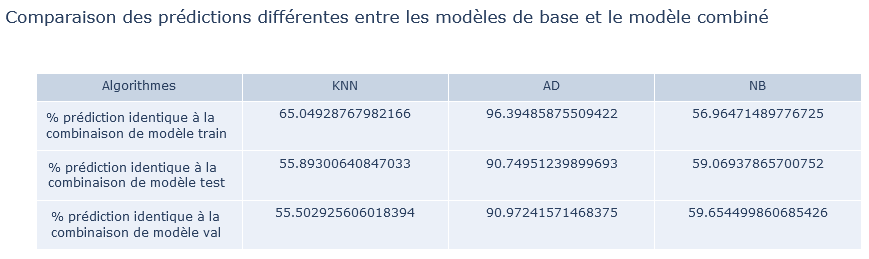

###  (2b): Résultats et résponses:

In [ ]:
# somme des proba prédites et choix de la proba la plus élevée.
def classificateur_combine (modele1, modele2, modele3, weight1, weight2, weight3,  X, choix):
    taille = np.shape (X)[0]
    prediction = np.zeros ((taille))
    if (choix == "somme_ponderee"):
        return (np.argmax(np.add(np.add (modele1.predict_proba (X) * weight1, \
                                            modele2.predict_proba (X) * weight2), \
                                            modele3.predict_proba (X) * weight3), axis=1))
    elif (choix == "Max_ponederee"):
        return (np.argmax(np.add(np.max (modele1.predict_proba (X) * weight1, \
                                            modele2.predict_proba (X) * weight2), \
                                            modele3.predict_proba (X) * weight3), axis=1))
    return (prediction)

In [ ]:
predictionTrain = classificateur_combine(neigh, ADC, gnb, 3.5, 1, 1, xlda_train, "somme_ponderee")
predictionTest = classificateur_combine(neigh, ADC, gnb, 3.5, 1, 1, xlda_test, "somme_ponderee")
predictionVal = classificateur_combine(neigh, ADC, gnb, 3.5, 1, 1, xlda_eval, "somme_ponderee")

In [ ]:
print('La précision avec les données de training est de  : ',
      accuracy_score(ytrain, predictionTrain) *100, '%.')
print('La précision avec les données de test est de  : ',
      accuracy_score(ytest, predictionTest)*100, '%.')
print('La précision avec les données évaluation est de  : ',
      accuracy_score(yval, predictionVal)*100, '%.')

La précision avec les données de training est de  :  83.13769201295761 %.
La précision avec les données de test est de  :  36.58400668709947 %.
La précision avec les données évaluation est de  :  36.305377542490945 %.


In [ ]:
predictionTrain = classificateur_combine(neigh, ADC, gnb, 1, 1, 1, xlda_train, "somme_ponderee")
predictionTest = classificateur_combine(neigh, ADC, gnb, 1, 1, 1, xlda_test, "somme_ponderee")
predictionVal = classificateur_combine(neigh, ADC, gnb, 1, 1, 1, xlda_eval, "somme_ponderee")

In [ ]:
print('La précision avec les données de training est de  : ',
      accuracy_score(ytrain, predictionTrain) *100, '%.')
print('La précision avec les données de test est de  : ',
      accuracy_score(ytest, predictionTest)*100, '%.')
print('La précision avec les données évaluation est de  : ',
      accuracy_score(yval, predictionVal)*100, '%.')

La précision avec les données de training est de  :  96.33912710299906 %.
La précision avec les données de test est de  :  35.52521593758707 %.
La précision avec les données évaluation est de  :  35.69239342435219 %.


In [ ]:
comp_ADC_combin = [0, 0, 0]
comp_KNN_combin = [0, 0, 0]
comp_GNB_combin = [0, 0, 0]
comp_KNN_combin[0] = accuracy_score(neigh.predict (xlda_train), predictionTrain) *100
comp_KNN_combin[1] = accuracy_score(neigh.predict (xlda_test), predictionTest) *100
comp_KNN_combin[2] = accuracy_score(neigh.predict (xlda_eval), predictionVal) *100
comp_ADC_combin[0] = accuracy_score(ADC.predict (xlda_train), predictionTrain) *100
comp_ADC_combin[1] = accuracy_score(ADC.predict (xlda_test), predictionTest) *100
comp_ADC_combin[2] = accuracy_score(ADC.predict (xlda_eval), predictionVal) *100
comp_GNB_combin[0] = accuracy_score(gnb.predict (xlda_train), predictionTrain) *100
comp_GNB_combin[1] = accuracy_score(gnb.predict (xlda_test), predictionTest) *100
comp_GNB_combin[2] = accuracy_score(gnb.predict (xlda_eval), predictionVal) *100

In [ ]:
import plotly.graph_objects as go
fig = go.Figure(data=[go.Table(header=dict(values=['Algorithmes','KNN', 'AD', 'NB']),
                               cells=dict(values=[ [
                                                   '% prédiction identique à la combinaison de modèle train',
                                                   '% prédiction identique à la combinaison de modèle test',
                                                   '% prédiction identique à la combinaison de modèle val'],
                                   comp_KNN_combin, comp_ADC_combin, comp_GNB_combin]))
                                    ])
fig.update_layout(
    title="Comparaison des prédictions différentes entre les modèles de base et le modèle combiné",
)
fig.show()

Problème pour copier les cellules avec exécution (go) de jupyter vers colab.

Copie de la capture d'écran du tableau

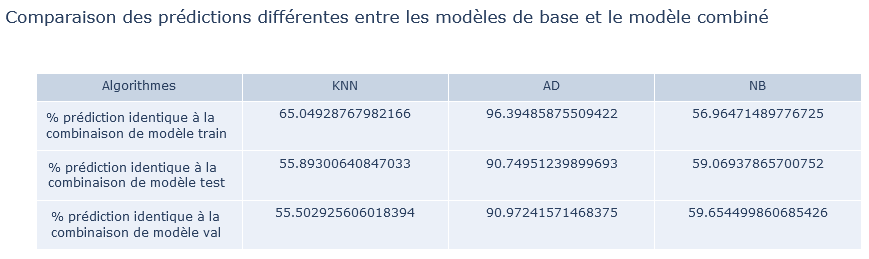

###  (2b): Résultats et résponses:

<font color='blue'> Nous avons repris les modèles de base de la partie 2.a. Ces modèles ont été entraînés sur toutes les données. Deux des modèles fournissent des probabilités de classification. KNN ne fournit que la classe prédite. Cela pose problème pour créer une combinaison de modèles. Nous avons donc choisi quand même d'utiliser une combinaison à somme de probabilités prédites et de retourner la classe ayant la probabilité la plus élevée. La seconde combinaison utilise la somme pondérée pour tenter de privilégier un modèle meilleur qu'un autre. Les 2 logigrammes suivants permettent de mieux comprendre notre raisonnement :


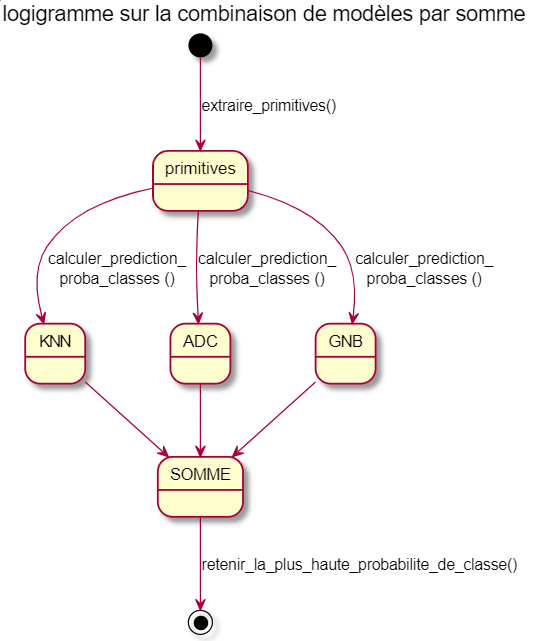

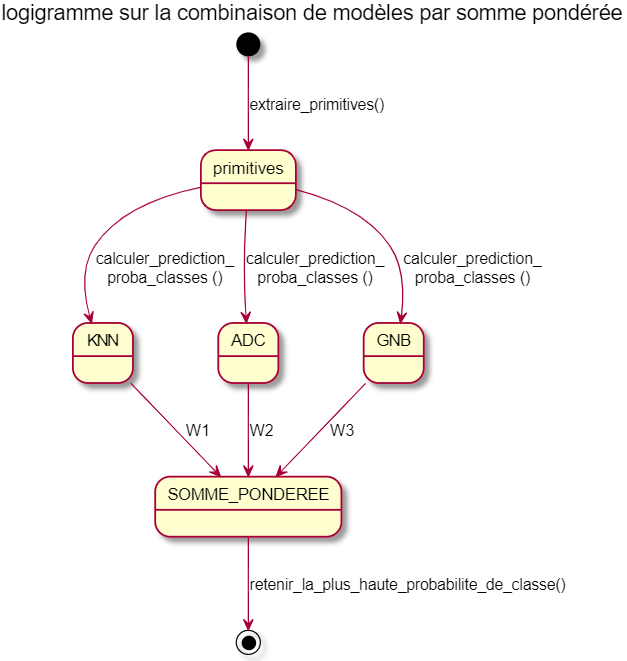

<font color='blue'> La somme pondérée permet de favoriser un modèle plutôt qu'un autre, ce qui peut être intéressant. Idéalement, les modèles devraient tous les trois prédire des probabilités par classe. Cela améliorerait la performance.


<font color='blue'> Pour la somme pondérée, on peut voir que les prédictions sur les tests sont légèrement plus élevées (gain d'au moins 1 % sur le meilleur modèle de base).

<font color='blue'> Enfin, le tableau intitulé "Comparaison des prédictions différentes entre les modèles de base et le modèle combiné" montre que la majeure partie des données du modèle combiné (entre 60 % et 90 %) sont les mêmes prédictions que les modèles de base. On peut donc conclure que cela ne modifie que très légèrement notre modèle et le complète par des modèles plus pertinents et complémentaires sur des données mal prédites. Notre modèle est plus robuste, car moins sujet à la variabilité des données. Cette amélioration est légère, car les modèles de base sont fortement corrélés (prédictions presque identiques). Il faudrait donc chercher d'autres méthodes/algorithmes/modèles plus indépendants.

# Partie 3: Régroupement
## (FER dataset)


Dans cette partie, nous allons ignorer les tâches <font color=magenta>de classification ou régression</font> les et les étiquettes. Nous allons supposer que les données sont non supervisées (non étiquetées).

Le but est de découvrir l’organisation des données, c.-à-d. découvrir les similitudes et les différences entre les données et d’en tirer des conclusions utiles (trouver des groupes cohérents).

Les tâches de regroupement
<font color=magenta>
- Identifier des groupes « naturels » dans les données;
- Discretiser un espace $\mathcal{R}^D$, en le séparant en $K$ régions. C'est equivalent à partitionner l’espace d’entrée en un certain nombre de « catégories » en se basant sur un ensemble d’apprentissage fini.
</font>


<font color=black>

### Partie (3a): Code régroupement (FER):
    
##### À faire :
1. Utiliser les algorithmes de regroupement de [scikit-learn clustering](https://scikit-learn.org/stable/modules/clustering.html#clustering)
2. Choisir deux algorithmes de regroupement <br>
    <font color=magenta>Vous devez également regarder le tableau [Overview of clustering methods](https://scikit-learn.org/stable/modules/clustering.html#overview-of-clustering-methods) pour voir quels sont les algorithmes de regroupement les plus appropriés en fonction des caractéristiques de l'ensemble de données FER (surtout « scalability » et « usecase »). (P.ex. $K$-means et hierarchical agglomerative. Voir le notebook exemple.)<br>
3. Entraîner et optimiser les paramètres des algorithmes de regroupement choisis. Utiliser l'ensemble de validation pour cette optimisation.<br>
4. Utiliser également l'ensemble de validation pour interpréter les résultats du regroupement. En regardant quelques exemples de chaque groupe, pouvons-nous assigner une étiquette fiable pour chaque groupe? P.ex. « Le groupe 0 représente l'émotion contente. Le groupe 1 représente l'émotion triste, etc. ».<br>
5. Faire une analyse des résultats et présenter vos conclusions sur l'interprétation des groupes trouvées. <br>
 - Analyser les groupes en supposant que les vraies étiquettes sont inconnues. <br>
 - Analyser les groupes en supposant que les vraies étiquettes sont connues.
     - Attention avec la consistance des étiquettes, c.-à-d., vous devez vous assurer d'avoir la bonne codification, chiffre = émotion.<br>
     - Dans le ground-truth nous avons 0 = Angry, 1 = Disgust, 2 = Fear, 3 = Happy, 4 = Sad, 5 = Surprise, 6 = Neutral, mais probablement vous n'allez pas avoir nécessairement cette même codification comme sortie d'algorithme de regroupement.
        
</font>    
</font>

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns; sns.set()  # for plot styling

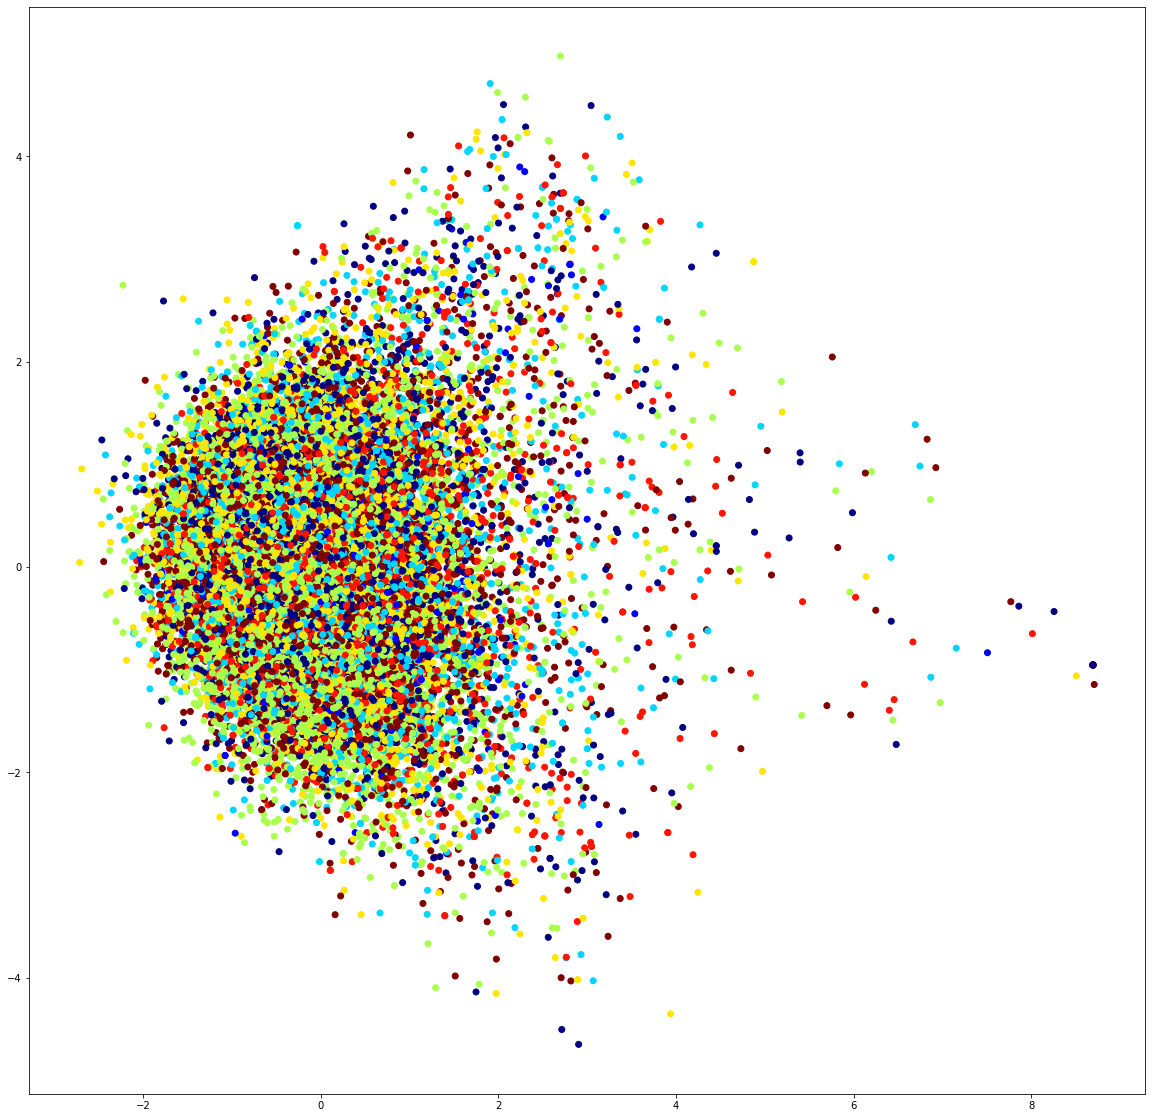

In [ ]:
plt.figure (figsize=(20, 20))
plt.scatter(xpca_train_norm[:, 0], xpca_train_norm[:, 1], c=ytrain[:], cmap=plt.cm.get_cmap('jet', 10))

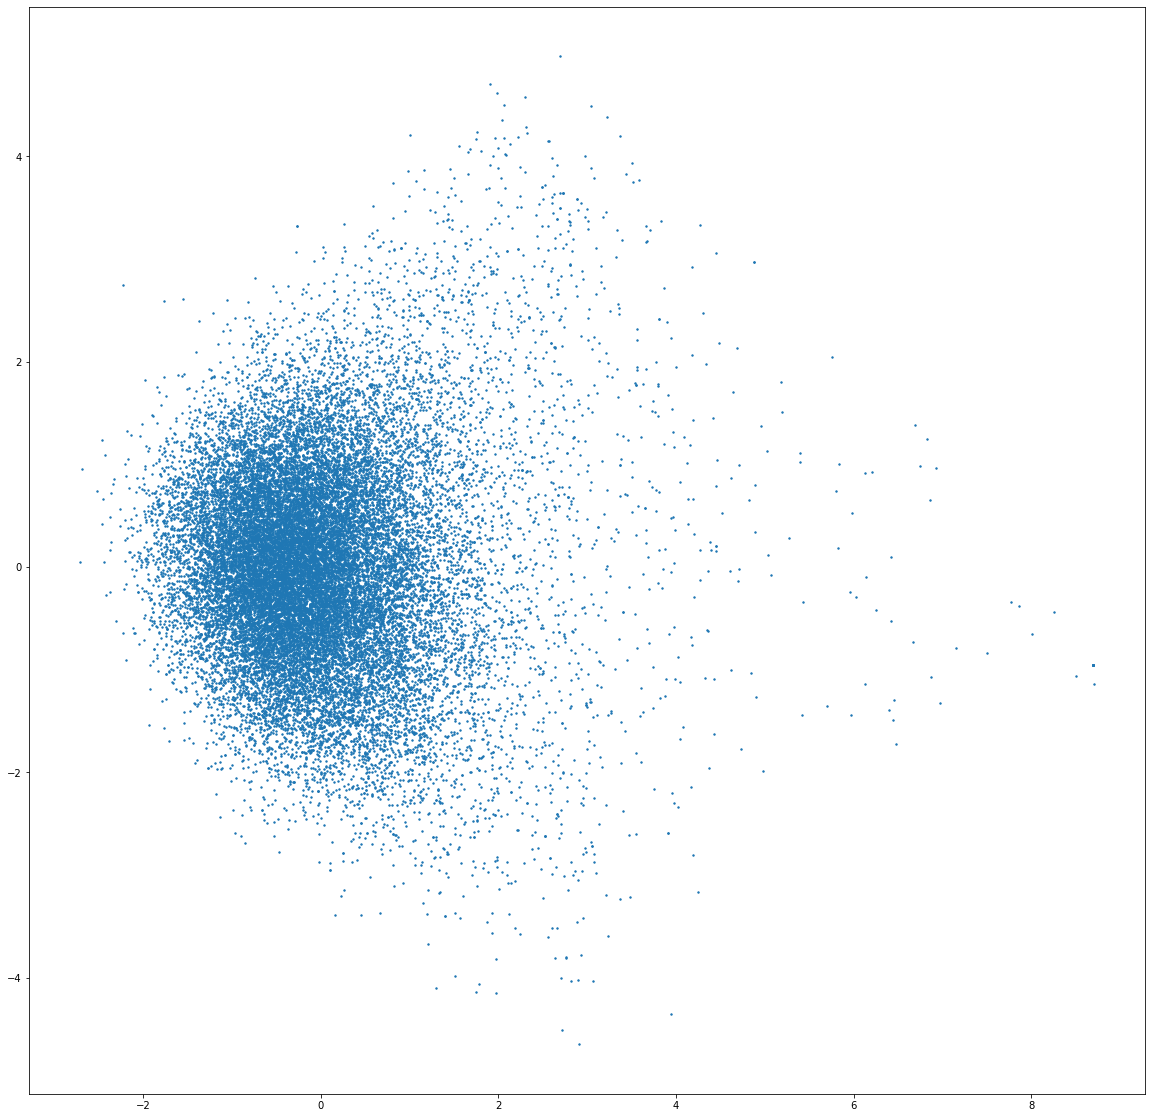

In [ ]:
plt.figure (figsize=(20, 20))
plt.scatter(xpca_train_norm[:, 0], xpca_train_norm[:, 1], s=2)

In [ ]:
from sklearn.cluster import KMeans
# Inspiré de https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_digits.html
kmeans_pca = KMeans(n_clusters=7, random_state=0).fit(xpca_train_norm)
y_kmeans_pca = kmeans_pca.predict(xpca_train_norm)

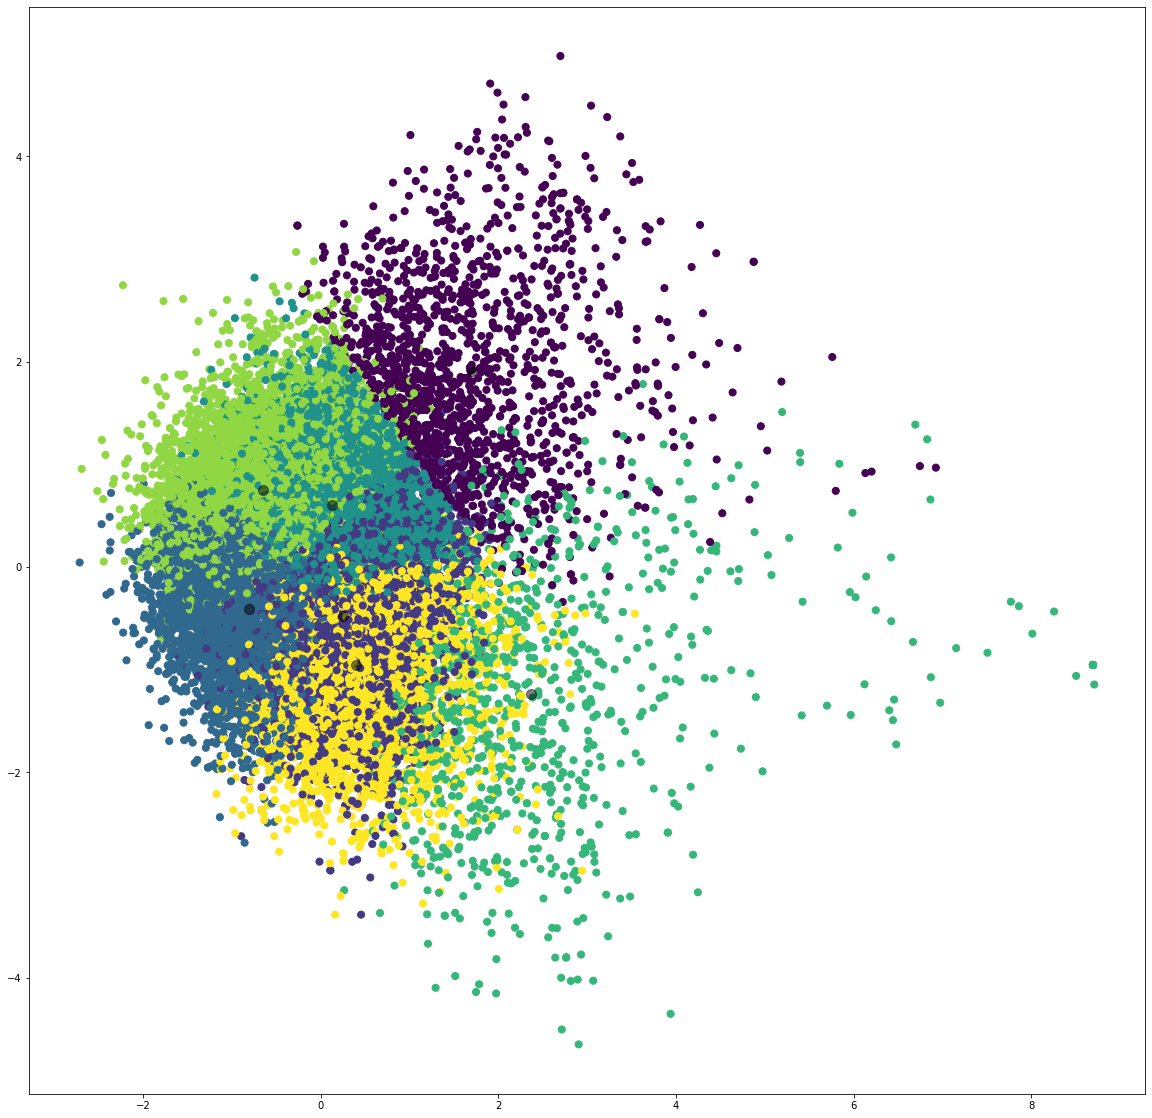

In [ ]:
plt.figure (figsize=(20, 20))
plt.scatter(xpca_train_norm[:, 0], xpca_train_norm[:,1], c=y_kmeans_pca, s=50, cmap='viridis')
centers = kmeans_pca.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=100, alpha=0.5)

In [ ]:
plt.figure (figsize=(20, 20))
plt.scatter(xpca_train_norm[:, 0], xpca_train_norm[:,1], c=y_kmeans, s=50, cmap='viridis')
centers = kmeans_pca.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=100, alpha=0.5)

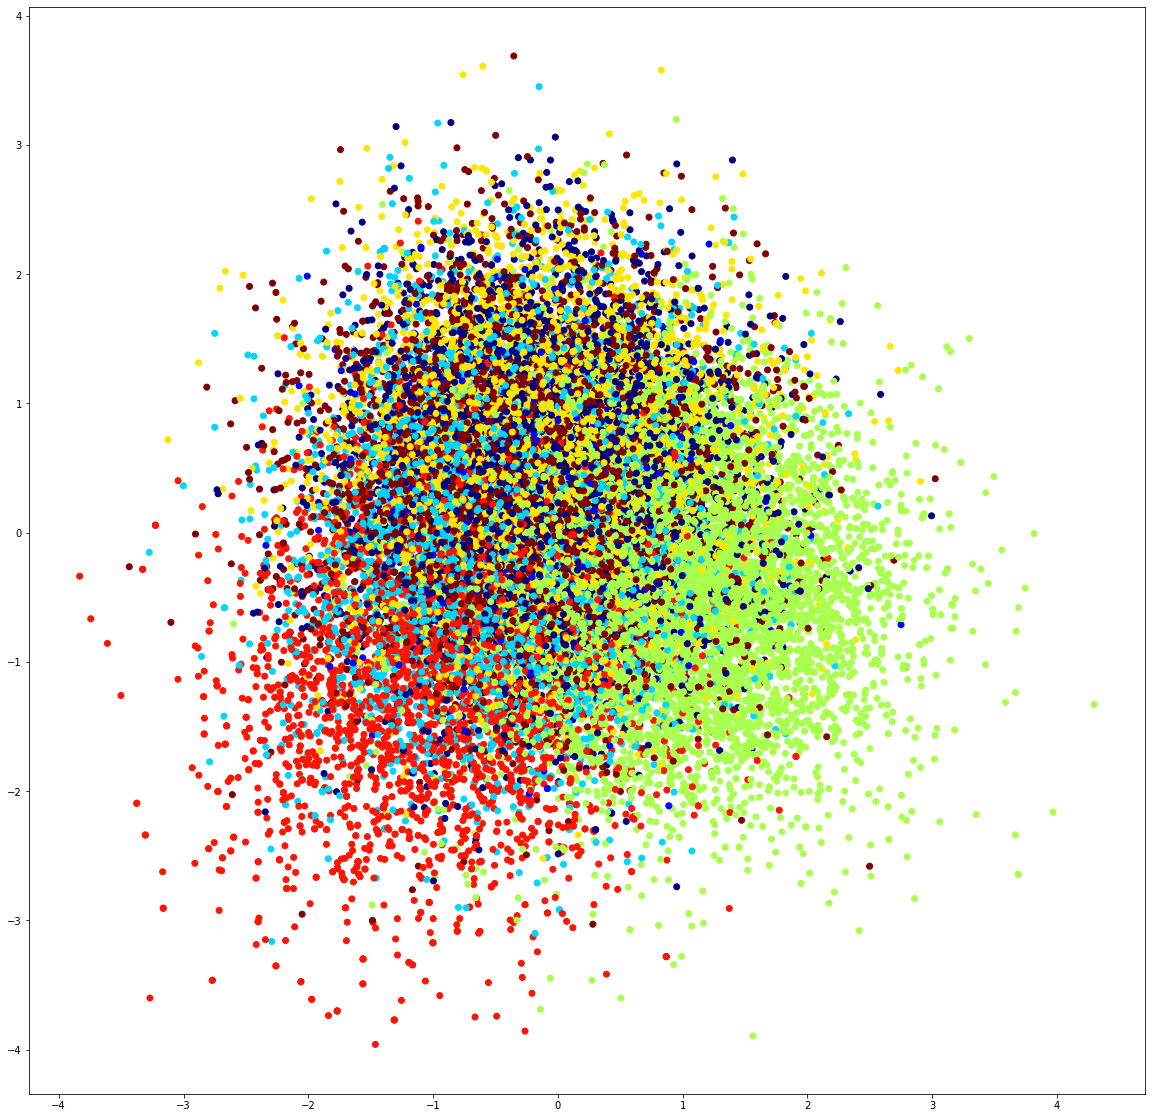

In [ ]:
plt.figure (figsize=(20, 20))
plt.scatter(xlda_train_norm[:, 0], xlda_train_norm[:, 1], c=ytrain[:], cmap=plt.cm.get_cmap('jet', 10))

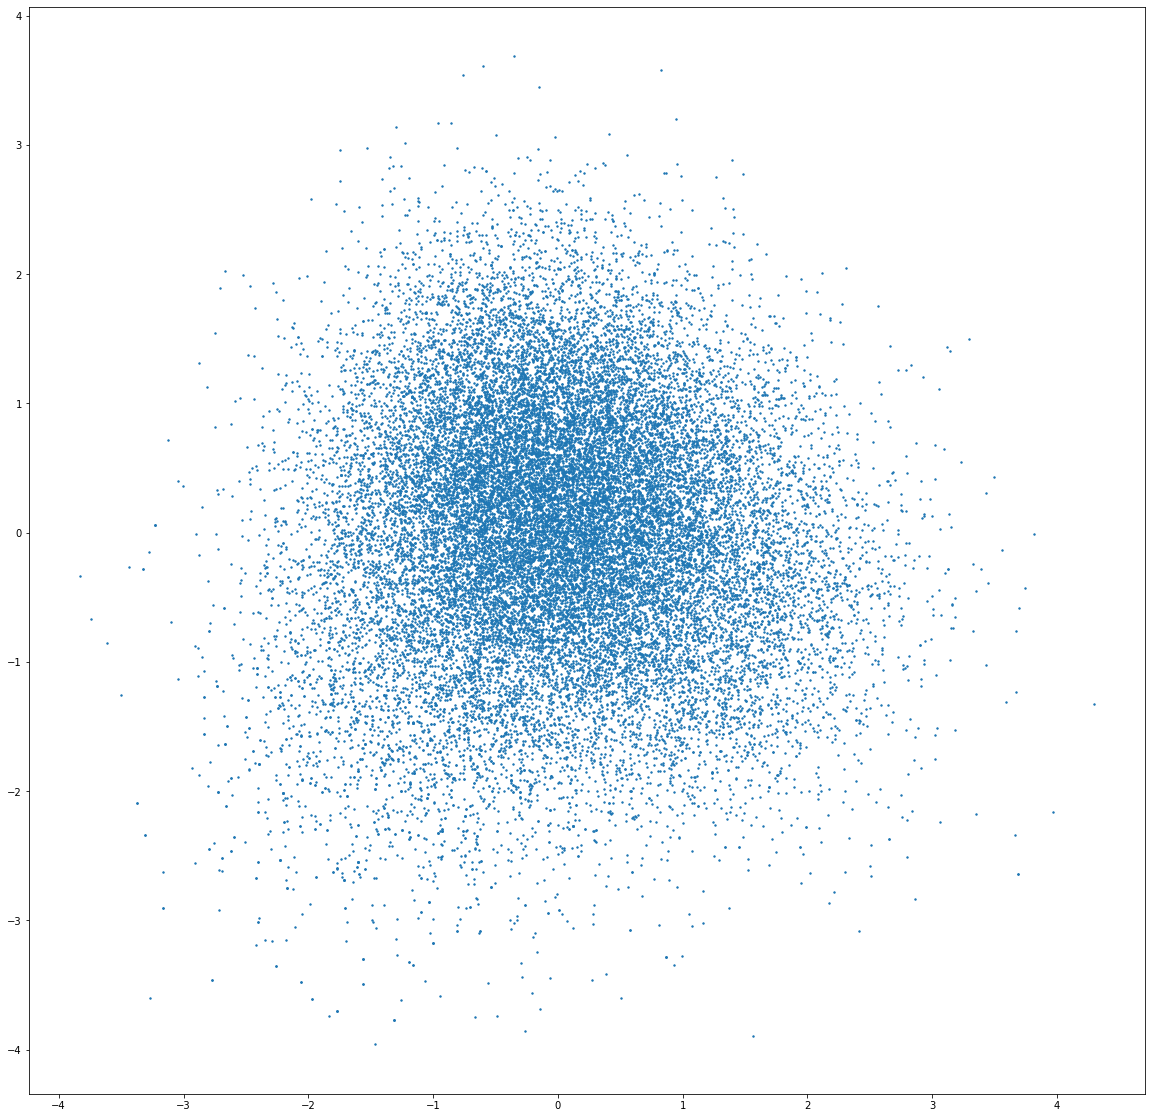

In [ ]:
plt.figure (figsize=(20, 20))
plt.scatter(xlda_train_norm[:, 0], xlda_train_norm[:, 1], s=2)

In [ ]:
kmeans_lda = KMeans(n_clusters=7, random_state=0).fit(xlda_train_norm)
y_kmeans_lda = kmeans_lda.predict(xlda_train_norm)

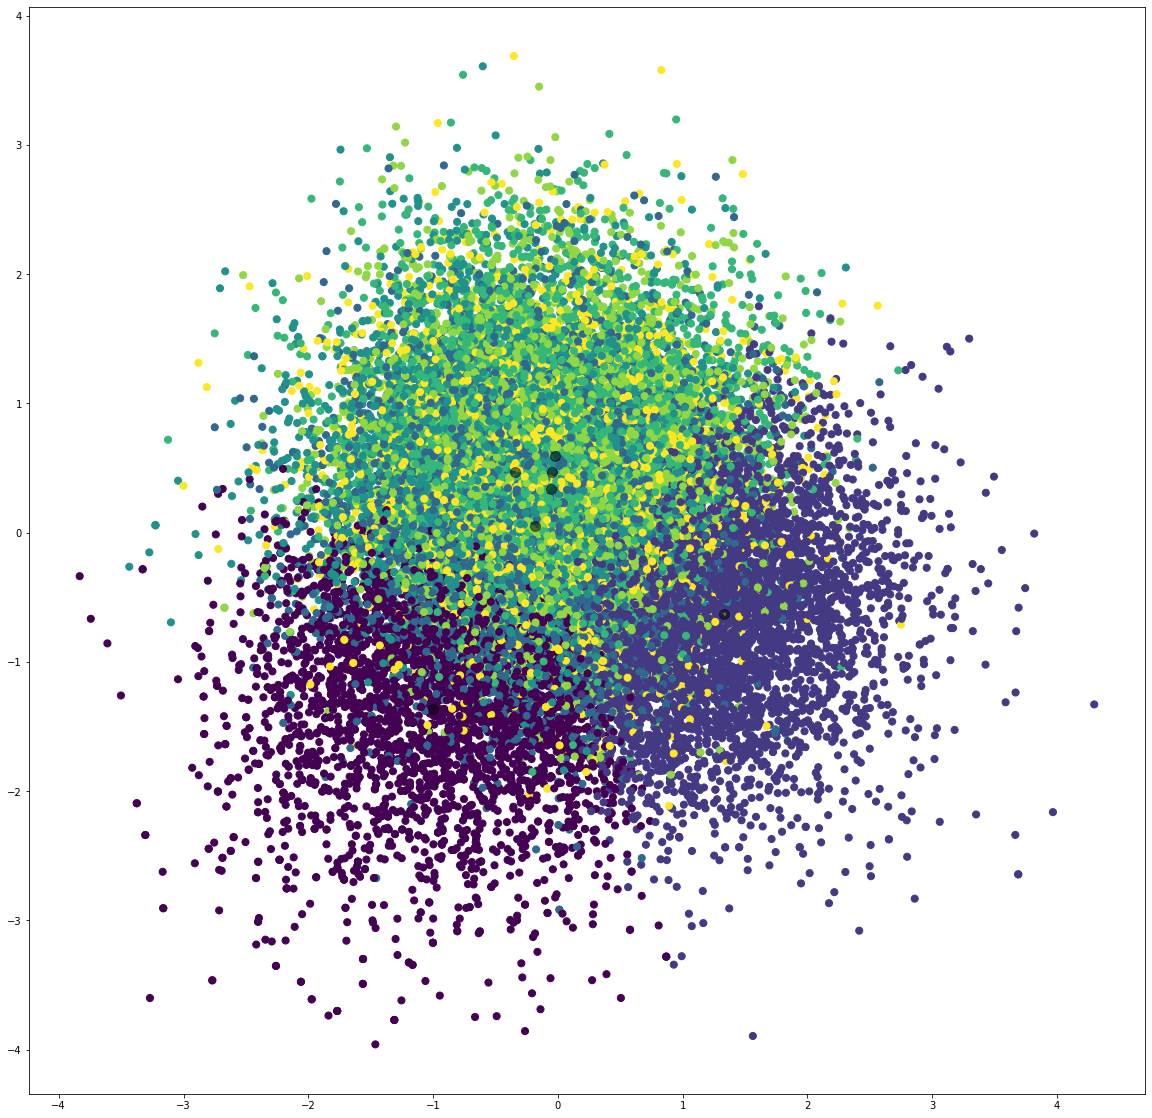

In [ ]:
plt.figure (figsize=(20, 20))
plt.scatter(xlda_train_norm[:, 0], xlda_train_norm[:,1], c=y_kmeans_lda, s=50, cmap='viridis')
centers = kmeans_lda.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=100, alpha=0.5)

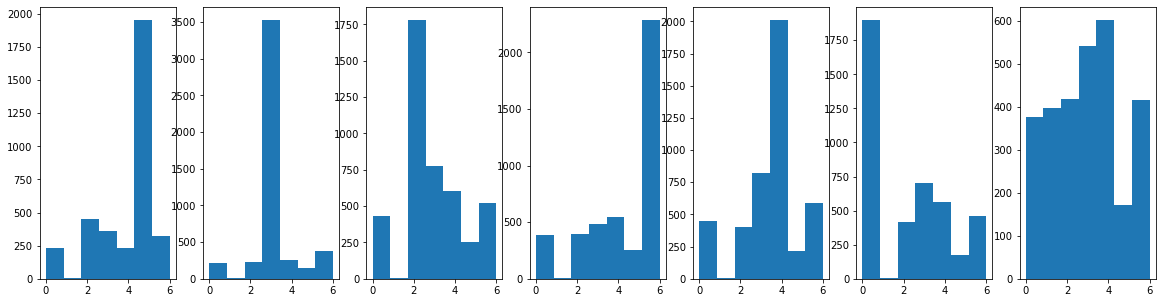

In [ ]:
# Supposition, on dispose de toutes les étiquettes -> recherche de l'étiquette la plus présente pour chaque classe
plt.figure(figsize=(20, 5))

for i in range(7):
    plt.subplot(1, 7, i+1)
    plt.hist((ytrain[y_kmeans_lda[:] == i])[:], bins = 7)

In [ ]:
association = {}
for i in range(7):
    counts = np.bincount((ytrain[y_kmeans_lda[:] == i])[:])
    association[i] = np.argmax(counts)

In [ ]:
print(association)

{0: 5, 1: 3, 2: 2, 3: 6, 4: 4, 5: 0, 6: 4}


In [ ]:
y_train_kmeans_pred = copy.deepcopy(y_kmeans_lda)
y_test_kmeans_pred = kmeans_lda.predict(xlda_test_norm)
y_val_kmeans_pred = kmeans_lda.predict(xlda_eval_norm)

for i in range(len(y_kmeans_lda)):
    y_train_kmeans_pred[i] = association[y_kmeans_lda[i]]
for i in range(len(y_test_kmeans_pred)):
    y_test_kmeans_pred[i] = association[y_test_kmeans_pred[i]]
for i in range(len(y_val_kmeans_pred)):
    y_val_kmeans_pred[i] = association[y_val_kmeans_pred[i]]

In [ ]:
# Evaluation du regroupement

y_kmeans_lda_train = kmeans_pca.predict(xpca_train_norm)

print('La précision avec les données de training est de  : ',
      accuracy_score(ytrain, y_train_kmeans_pred) *100, '%.')
print('La précision avec les données de test est de  : ',
      accuracy_score(ytest, y_test_kmeans_pred)*100, '%.')
print('La précision avec les données évaluation est de  : ',
      accuracy_score(yval, y_val_kmeans_pred)*100, '%.')

La précision avec les données de training est de  :  48.981155735135324 %.
La précision avec les données de test est de  :  31.958762886597935 %.
La précision avec les données évaluation est de  :  32.01448871551965 %.


### Partie (3a): Résultats et résponses:

Nous avons décidé de prendre les algorithmes Knn et Spectral clustering.
K-means est rapide et relativement adapté à nos données.
Spectral clustering est plus adapté à un ensemble de données de taille "moyenne" et un petit nombre de classes. Sprectral clustering n'a pas pu être appliqué, car cela nécessite trop de RAM.


Les données semblent réparties autour d'un centre. Visuellement, les classes ne sont pas bien séparables. Ainsi, le clustering ne semble pas très pertinent dans notre cas.
Nous avons donc décidé de ne pas appliquer d'optimisation, car cela n'a pas de sens.

Finalement, le clustering offre de bons résultats. La visualisation est faite en 2D alors que nous disposons de 6D. Cela explique pourquoi la première interprétation à partir de la visualisation est incorrecte.

Si nous ne faisons pas la supposition de connaître les classes avant, nous ne pouvons pas associer les groupes issus du regroupement à une classe prédite. Cela n'a pas de sens. Eventuellement, nous pourrions prédire avec la supposition que nous détenons très peu d'étiquettes. Statistiquement, nous obtiendrons les mêmes résultats, mais cela dépend du nombre d'étiquettes.

Les histogrammes montrent que les regroupements prédisent bien 1 classe, sauf pour la dernière classe qui est moins évidente.

Finalement, nous perdons environ 3 % de pouvoir prédictif. L'apprentissage est néanmoins totalement non supervisé. Il suffirait de quelques étiquettes (centaine environ) pour faire l'association des regroupements avec les vraies classes correctement.

# Partie Final: Conclusion

##### À faire (SVM et SVR):

1. Décrivez la méthode de normalisation de données utilisée.
2. Présentez brièvement la méthode que vous avez utilisée afin de trouver le meilleur modèle SVM. Quels ont été vos résultats ? Quels sont les impacts des hyperparamètres et leur utilité respective?
3. Globalement, prenant en compte les trois TPs, quel type d’approche recommanderiez-vous pour les ensembles de données FER et FG-NET et dans quelles conditions (par exemple, mais non exhaustif, le nombre de données privilégié, les hyperparamètres, le temps de calcul, le matériel nécessaire, les scores de performance)? Discutez des performances que vous avez obtenues entre tous les modèles d’apprentissage.
4. Formulez quelques pistes d’amélioration des classificateurs.<br>

<font color=magenta>
    
##### À faire (Combinaison de modèles):
1. Présentez la conception de votre solution reposant sur la théorie des ensembles. Présentez ici le diagramme nécessaire afin de présenter convenablement votre combinaison de modèles. Faites une discussion expliquant vos décisions de conception.
2. Est-ce que la combinaison de modèles a apporté des améliorations dans les performances? Comparer la combinaison de modèles avec les modèles individuels.
    
    
##### À faire (Regroupement):    
1. Présentez vos conclusions sur les algorithmes de regroupement. Sont-ils vraiment utiles? Ont-ils produit des résultats cohérents? Est-ce que c’est facile à analyser les sorties (groupes) et d'en tirer des conclusions sur quelles étiquettes assigner à ces groupes?
    
</font>    

### Partie Final: Résultats et résponses:

#### Votre réponse ici:

Partie (SVM/SVR) :
- Une validation croisée sur trois hyperparamètres a été faite (type de modèle, C, gamma et le nombre de degré du poylnôme);

Nous avons obtenu les résultats suivants:


|  Primitive   | Noyau       |   Paramètres    |  % train | % Val  | % Test  |
|--------------|-------------|-----------------|--------|--------|--------|
| LBP avec PCA | lineaire    | C=0.001            | 25.53 | 24.85 | 25.44       |
| LBP avec PCA | polynomial    | C=0.001 deg = 2 | 25.97 | 24.91 | N.A.       |
| LBP avec PCA | RBF    | C=0.001 gamma = 0.1 | 25.13 | 24.49 | N.A.       |
| CNN simple     | lineaire    | C=0.001  | 25.13 | 24.49 |   N.A.      |
| CNN simple     | polynomial    | C=0.01 deg = 2 | 25.13 | 24.49 |   N.A.      |
| CNN simple     | RBF    | C=0.01  gamma = 0.1  | 25.13 | 24.49 |   N.A. |
| LBPH 36 avec LDA | linéaire  | C=10 | 41.01 | 33.68 | 33.04 |
| LBPH 100 avec LDA | linéaire   | C=1  | 52.88 | 36.42 | 36.03 |
| LBPH 100 avec LDA | polynomial | C=1, deg = 2  | 53.92 | 36.17 | 35.92 |
| LBPH 100 avec LDA | RBF         | C=1 gamma=0.1  | 54.00 | 35.89 | 35.75 |

Comme l'optimisation des paramètres privilégie le degré le plus bas et le gamma le plus bas, nous pouvons déduire que les classes sont linéairement séparables. Le modèle linéaire avec C = 1 est le modèle le plus performant.

Par rapport aux laboratoires n°1 et n°2, nous n'utilisons pas les mêmes primitives. Les résultats sont nettement supérieurs pour ce laboratoire. Nous pouvons conclure que l'extraction de primitives est essentielle et doit être bien recherchée. Toutefois, les modèles SVM et SVR sont des modèles performants. Nous obtenons 36 % de performance sur les données de test.

Afin d'améliorer les performances, il faudrait combiner plus de primitives extraites différemment (inclure les filtres de gabor par exemple). Il faudrait également trier les données pour entraîner correctement les modèles. Enfin, il faudrait plus d'images pour notre ensemble de données.

Partie (Combinaison de modèles, bagging & boosting) :

Un gain en performance a été relevé. Ceci est normal, car nous entraîner des modèles sur des données partiels et les combinons (bagging). On peut également entraîner un modèle sur les mauvais résultats de l'autre modèle (boosting). L'adaboost utilise une "amélioration adaptative" en utilisant le principe de boosting, mais évite de surentrainer sur ces données en gérant la proportion d'entraînement sur les données mal prédites et bien prédites.

Partie (Regroupement) :

Les données sont regroupées en classe. Visuellement, les classes ne sont pas bien séparables (2D), mais elles le sont en réalité sur les 6 composantes. On peut conclure que cette méthode donne un résultat très similaire au SVM. Cela peut être intéressant dans le cas où l'étiquetage des entrées est très coûteuse.

Conclusion générale :
Nos modèles sont bien robustes que les modèles des premiers laboratoires. Cela est dû à l'extraction de primitives. Pour obtenir des modèles très performants, il faudrait utiliser (en complément avec combinaison, bagging et boosting) des modèles plus sophistiqués du laboratoire n°2 comme les CNN ou réseaux de neurones multicouches. Comme notre ensemble de données comporte beaucoup de données complexes à interpréter, on peut booster un modèle complexe sur ces données, tout en s'assurant que nous ne faisons pas de surentrainement (AdaBoost).